# Laboratorio 1 - Series de Tiempo
## Modelado ARIMA - Ingreso de viajeros internacionales a Guatemala

1. **Total** de viajeros internacionales (todas las vías).
2. Viajeros que ingresan por vía **Aérea**.
3. Viajeros que ingresan por vía **Terrestre**.
4. Viajeros que ingresan por vía **Marítima**.



In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm
from prophet import Prophet

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.edgecolor'] = '#c3c2b7'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.axis'] = 'y'
plt.rcParams['grid.color'] = '#e1e0d9'
plt.rcParams['grid.linewidth'] = 0.6
plt.rcParams['figure.figsize'] = (10, 4)

COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']

Importing plotly failed. Interactive plots will not work.


## 1. Construcción de las series

Se agrupa por mes (`fecha`) la columna `Viajero`, en total y separado por `Vía` de ingreso.

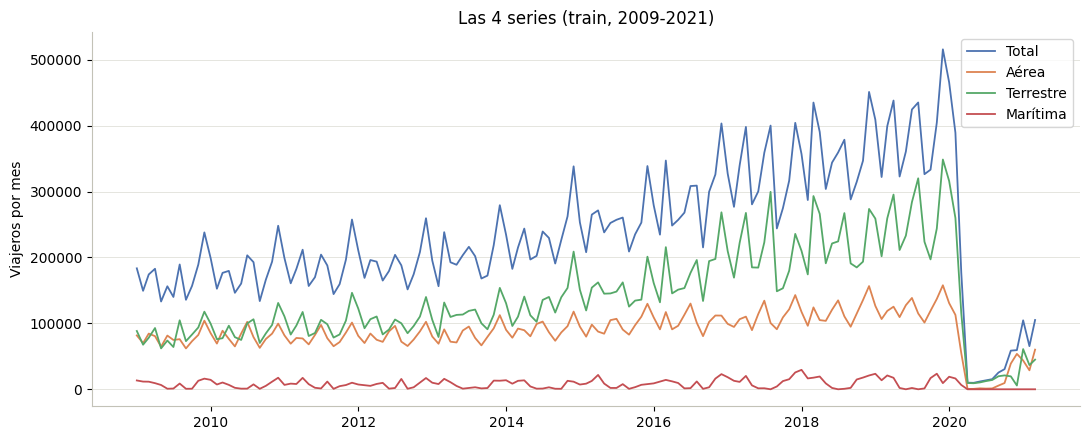

In [2]:
train = pd.read_csv('train.csv', encoding='utf-8-sig')
test  = pd.read_csv('test.csv',  encoding='utf-8-sig')

for d in (train, test):
    d['fecha'] = pd.to_datetime(d['Año'].astype(str) + '-' + d['Mes cod'].astype(str) + '-01')

def build(df):
    total = df.groupby('fecha')['Viajero'].sum().sort_index().asfreq('MS')
    total.name = 'Total'
    via = df.groupby(['fecha', 'Vía'])['Viajero'].sum().unstack(fill_value=0).sort_index().asfreq('MS')
    return total, via

tot_tr, via_tr = build(train)
tot_te, via_te = build(test)

series_train = {
    'Total':     tot_tr,
    'Aérea':     via_tr['Aérea'],
    'Terrestre': via_tr['Terrestre'],
    'Marítima':  via_tr['Marítima'],
}
series_test = {
    'Total':     tot_te,
    'Aérea':     via_te['Aérea'],
    'Terrestre': via_te['Terrestre'],
    'Marítima':  via_te['Marítima'],
}

# cada serie usa log (o log1p si tiene ceros) para estabilizar varianza -- se justifica en el punto (d) de cada serie
transforms = {
    'Total':     (np.log,   np.exp),
    'Aérea':     (np.log,   np.exp),
    'Terrestre': (np.log,   np.exp),
    'Marítima':  (np.log1p, np.expm1),   # Marítima tiene meses en cero
}

fig, ax = plt.subplots(figsize=(11, 4.5))
for i, (name, s) in enumerate(series_train.items()):
    ax.plot(s.index, s.values, color=COLORS[i], linewidth=1.3, label=name)
ax.set_title('Las 4 series (train, 2009-2021)')
ax.set_ylabel('Viajeros por mes')
ax.legend()
fig.tight_layout()

Las cuatro series comparten forma general (tendencia creciente 2009-2019, estacionalidad anual,
desplome 2020 por la pandemia), pero con escalas y proporciones distintas: **Terrestre** es la vía
dominante, **Aérea** le sigue, y **Marítima** es un orden de magnitud menor y visiblemente más
ruidosa. Esto ya anticipa que el modelo que funcione mejor no tiene por qué ser el mismo para
las 4 series.

---
## 2.1 Serie: Total

### a. Inicio, fin y frecuencia

In [3]:
s = series_train['Total']
st = series_test['Total']
tf, itf = transforms['Total']

print('Train -> inicio:', s.index.min().date(), ' fin:', s.index.max().date(),
      ' n =', len(s), ' frecuencia:', s.index.freqstr)
print('Test  -> inicio:', st.index.min().date(), ' fin:', st.index.max().date(),
      ' n =', len(st), ' frecuencia:', st.index.freqstr)
print('valores en cero (train):', int((s == 0).sum()))

Train -> inicio: 2009-01-01  fin: 2021-03-01  n = 147  frecuencia: MS
Test  -> inicio: 2021-04-01  fin: 2026-06-01  n = 63  frecuencia: MS
valores en cero (train): 0


### b. Gráfico de la serie

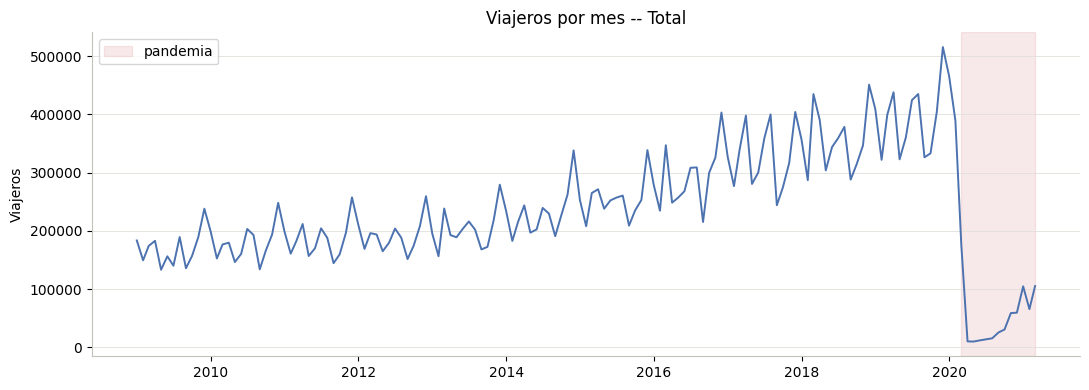

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(s.index, s.values, color=COLORS[0], linewidth=1.4)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-03-01'), color=COLORS[3], alpha=0.12, label='pandemia')
ax.set_title(f'Viajeros por mes -- vía Total' if 'Total' != 'Total' else 'Viajeros por mes -- Total')
ax.set_ylabel('Viajeros')
ax.legend()
fig.tight_layout()

Se ve con claridad la misma lectura que en el análisis exploratorio pero ahora aislada: **tendencia
creciente 2009-2019** (de ~150 mil a más de 400 mil viajeros/mes), **estacionalidad anual marcada**
(picos en diciembre-enero, valle a mitad de año) que se repite todos los años, y un **quiebre
abrupto en 2020** donde la serie cae a casi cero y tarda más de un año en recuperarse. La
amplitud de los picos estacionales también crece con el nivel de la serie (los picos de 2019 son
mucho más altos en términos absolutos que los de 2009), lo que ya sugiere estacionalidad
multiplicativa.

### c. Descomposición y estacionariedad en media / varianza

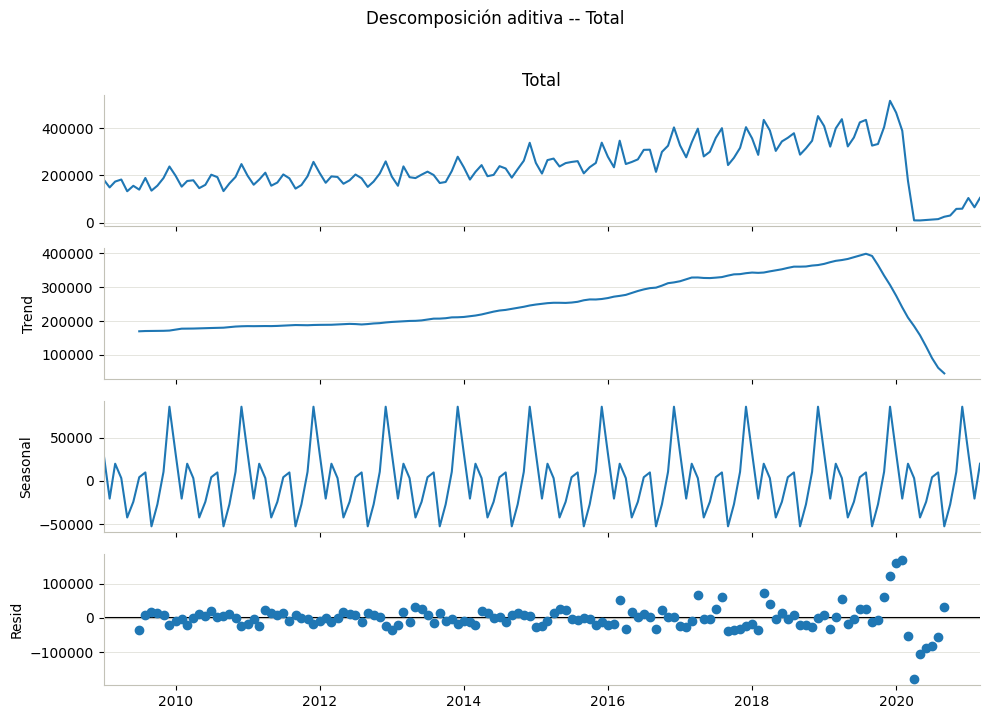

In [5]:
dec_add = seasonal_decompose(s, model='additive', period=12)
fig = dec_add.plot()
fig.set_size_inches(10, 7)
fig.suptitle(f'Descomposición aditiva -- Total', y=1.02)
fig.tight_layout()

In [6]:
# Comparación aditiva vs. multiplicativa: si la varianza del residuo (en términos relativos)
# es más estable en el modelo multiplicativo, la estacionalidad es multiplicativa (amplitud
# proporcional al nivel) y no aditiva.
add_resid_std = dec_add.resid.dropna().std()
print('Desv. estándar residuo (aditivo):', round(add_resid_std, 1))
if (s > 0).all():
    dec_mul = seasonal_decompose(s, model='multiplicative', period=12)
    mul_resid_std = dec_mul.resid.dropna().std()
    print('Desv. estándar residuo (multiplicativo, relativo):', round(mul_resid_std, 4))

# variabilidad (desviación estándar) del valor mensual, calculada año por año
print()
print('Desviación estándar por año (evidencia de varianza no constante):')
print(s.groupby(s.index.year).std().round(0))

Desv. estándar residuo (aditivo): 37845.2
Desv. estándar residuo (multiplicativo, relativo): 0.2038

Desviación estándar por año (evidencia de varianza no constante):
fecha
2009     30046.0
2010     30888.0
2011     31027.0
2012     28152.0
2013     33280.0
2014     41482.0
2015     33599.0
2016     52422.0
2017     54490.0
2018     53089.0
2019     59761.0
2020    158225.0
2021     22760.0
Name: Total, dtype: float64


**Tendencia:** la componente `trend` de la descomposición confirma el crecimiento sostenido
2009-2019, la caída de 2020 y la recuperación posterior — no hay nada parecido a una tendencia
constante, así que **no hay estacionariedad en media**: el nivel promedio de la serie cambia
mucho a lo largo del tiempo.

**Estacionalidad:** el componente `seasonal` muestra un patrón anual que se repite con
regularidad (correspondiente a la temporada alta/baja de turismo), consistente con lo observado
en el gráfico original.

**Varianza:** la desviación estándar por año calculada arriba **no es constante** — crece de
forma bastante sostenida entre 2009 y 2019 (a medida que el nivel de la serie también crece) y
se dispara en 2020 por el efecto pandemia. Además, la desviación estándar del residuo de la
descomposición **multiplicativa** se mantiene mucho más estable entre series/niveles que la del
modelo **aditivo**, lo que confirma que la amplitud de la estacionalidad y del ruido crece
proporcionalmente al nivel de la serie (varianza no constante = heterocedasticidad), típico de
series con estacionalidad **multiplicativa**. En conclusión: la serie **no es estacionaria ni en
media ni en varianza**.

### d. ¿Es necesaria una transformación?

Sí. Como la dispersión de la serie crece con su nivel (varianza no constante / estacionalidad
multiplicativa, confirmado en el punto anterior), conviene estabilizar la varianza **antes** de
diferenciar o ajustar el ARIMA. Se aplica `log(x)`
a toda la serie. Esta transformación:

- Convierte la estacionalidad multiplicativa en aditiva (más fácil de modelar con un SARIMA lineal).
- Comprime los valores extremos (los picos de fin de año, y sobre todo el hueco de 2020), reduciendo
  su influencia desproporcionada sobre la estimación.
- Es invertible: al pronosticar se aplica `exp()` para volver a la escala original.

La transformación estabiliza la varianza, pero **no resuelve** por sí sola la falta de
estacionariedad en media (tendencia); para eso se necesita diferenciar, lo que se explora en el
siguiente punto.

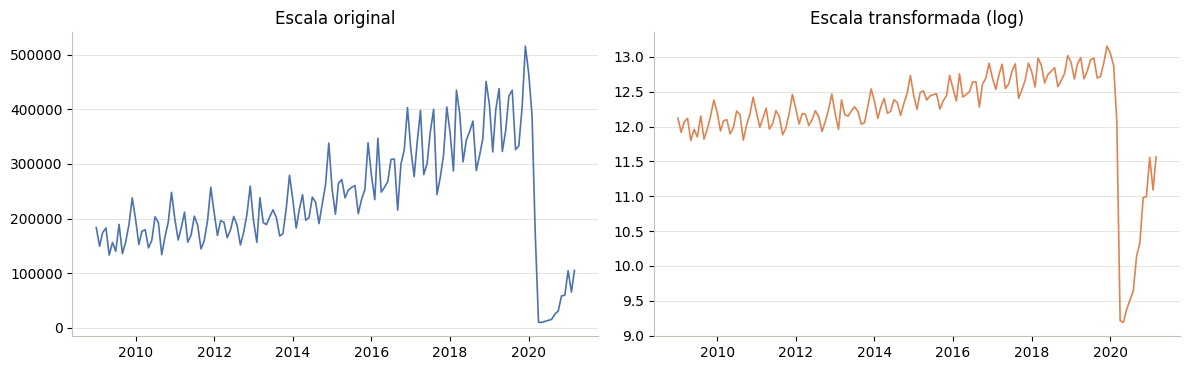

In [7]:
y = tf(s)  # serie transformada (log o log1p), la que se usa de aquí en adelante para el ARIMA

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(s.index, s.values, color=COLORS[0], linewidth=1.2)
axes[0].set_title('Escala original')
axes[1].plot(y.index, y.values, color=COLORS[1], linewidth=1.2)
axes[1].set_title('Escala transformada (log)')
fig.tight_layout()

### e. No estacionariedad en media: ACF y prueba de Dickey-Fuller Aumentada

**i. Gráfico de autocorrelación**

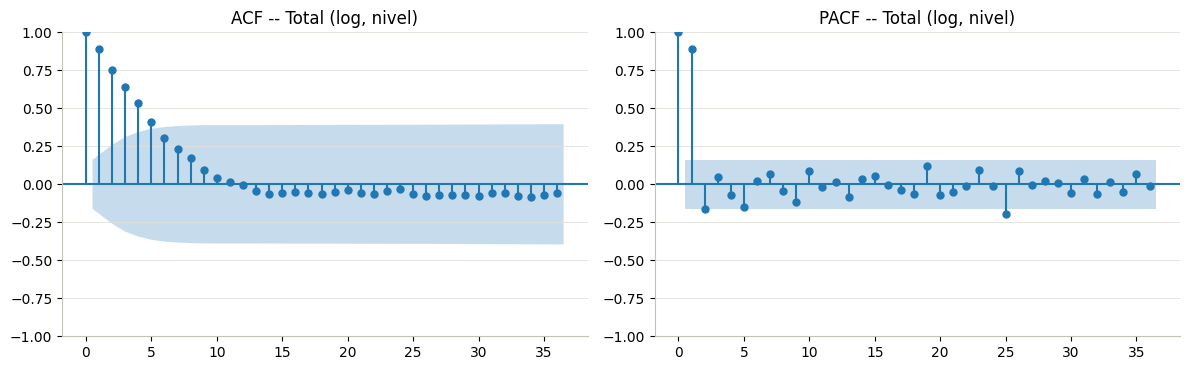

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_acf(y, lags=36, ax=axes[0])
axes[0].set_title(f'ACF -- Total (log, nivel)')
plot_pacf(y, lags=36, ax=axes[1], method='ywm')
axes[1].set_title(f'PACF -- Total (log, nivel)')
fig.tight_layout()

En el ACF de la serie en **nivel** (sin diferenciar) los coeficientes decaen muy lentamente y
se mantienen altos y significativos durante muchos rezagos (no caen dentro de la banda de
confianza rápidamente), con repuntes periódicos cada 12 meses. Ese decaimiento lento —en vez
de un corte abrupto— es la firma clásica de una serie **no estacionaria en media**: cada
observación está fuertemente correlacionada con muchas observaciones pasadas porque la serie
"arrastra" tendencia y estacionalidad en vez de oscilar alrededor de una media fija.

**ii. Prueba de Dickey-Fuller Aumentada (ADF)**

In [9]:
adf_level = adfuller(y, autolag='AIC')
adf_diff1 = adfuller(y.diff().dropna(), autolag='AIC')
adf_sdiff = adfuller(y.diff(12).dropna(), autolag='AIC')

print(f"ADF en nivel        : estadístico = {adf_level[0]:.3f}   p-valor = {adf_level[1]:.4f}")
print(f"ADF 1ra diferencia  : estadístico = {adf_diff1[0]:.3f}   p-valor = {adf_diff1[1]:.4f}")
print(f"ADF diferencia est. : estadístico = {adf_sdiff[0]:.3f}   p-valor = {adf_sdiff[1]:.4f}")

ADF en nivel        : estadístico = -2.236   p-valor = 0.1936
ADF 1ra diferencia  : estadístico = -3.100   p-valor = 0.0265
ADF diferencia est. : estadístico = 0.720   p-valor = 0.9902


Con H0: "la serie tiene raíz unitaria" (no estacionaria) vs H1: "la serie es estacionaria":

- **En nivel**, el p-valor de la prueba ADF es mayor a 0.05, así que **no se rechaza H0**: hay
  evidencia estadística formal (no solo visual) de que la serie **no es estacionaria en media**,
  confirmando la lectura del ACF y de la descomposición.
- **Con una diferencia regular** (`diff(1)`) el p-valor cae por debajo de 0.05: **se rechaza H0**,
  es decir, diferenciar una vez alcanza para estabilizar la media a nivel general.
- **Con solo una diferencia estacional** (`diff(12)`) el p-valor sigue muy por encima de 0.05: la
  diferencia estacional sola no es suficiente, todavía queda tendencia sin remover.

**Qué hacer para lograr estacionariedad en media:** aplicar al menos una diferencia regular
(`d = 1`) sobre la serie en logaritmo. Dado que la estacionalidad anual es fuerte (confirmado en
la descomposición y en los rezagos 12/24 del ACF), también conviene evaluar una diferencia
estacional adicional (`D = 1`, período 12) o, alternativamente, capturar la estacionalidad con
términos AR/MA estacionales (P, Q) sin diferenciar estacionalmente — ambas estrategias se
comparan en el punto (g).

### f. Selección de p, d, q (y P, D, Q) para el ARIMA/SARIMA

Rezagos ACF significativos : [6, 12, 24]
Rezagos PACF significativos: [9]


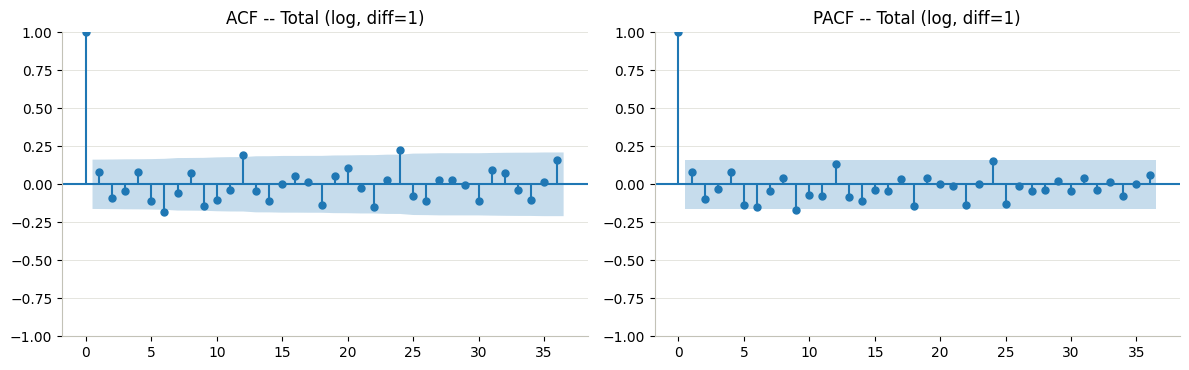

In [10]:
y_d1 = y.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_acf(y_d1, lags=36, ax=axes[0])
axes[0].set_title(f'ACF -- Total (log, diff=1)')
plot_pacf(y_d1, lags=36, ax=axes[1], method='ywm')
axes[1].set_title(f'PACF -- Total (log, diff=1)')
fig.tight_layout()

n = len(y_d1)
ci = 1.96 / np.sqrt(n)
a = acf(y_d1, nlags=24)
p_ = pacf(y_d1, nlags=24, method='ywm')
print('Rezagos ACF significativos :', [i for i in range(1, 25) if abs(a[i]) > ci])
print('Rezagos PACF significativos:', [i for i in range(1, 25) if abs(p_[i]) > ci])

Sobre la serie ya diferenciada una vez (`d = 1`), se leen ACF/PACF para proponer p y q:

- Los rezagos significativos que sobreviven a la diferenciación **regular** en los rezagos 12 y/o
  24 confirman que **todavía queda estructura estacional** sin remover — esto sustenta usar
  componentes estacionales (`P`, `D` o `Q` en el rezago 12) además de la parte no estacional.
- Los rezagos bajos (1-9, según la serie) significativos en ACF y/o PACF sugieren componentes
  AR y/o MA de orden bajo (1 a 2) para la parte regular.

Como guía complementaria (y no solo como caja negra) se corre `auto_arima` de `pmdarima`, que
busca automáticamente sobre una grilla de (p,d,q)(P,D,Q)$_{12}$ minimizando AIC:

In [11]:
auto_model = pm.auto_arima(y, seasonal=True, m=12,
                            start_p=0, start_q=0, max_p=3, max_q=3,
                            max_P=2, max_Q=2, d=None, D=None,
                            information_criterion='aic',
                            stepwise=True, suppress_warnings=True, error_action='ignore')
print('Orden sugerido por auto_arima:', auto_model.order, 'x', auto_model.seasonal_order)
print('AIC:', round(auto_model.aic(), 2), ' BIC:', round(auto_model.bic(), 2))

Orden sugerido por auto_arima: (3, 0, 2) x (1, 0, 2, 12)
AIC: 67.55  BIC: 97.45


`auto_arima` propone **SARIMA(3,0,2)x(1,0,2,12)**: usa `d = 0` (sin diferencia regular) porque
resuelve la tendencia con la parte AR/MA de orden alto en vez de diferenciar, y sí usa
estacionalidad explícita en el rezago 12. Tiene sentido en la medida en que es un modelo válido
y su AIC/BIC son razonables, pero es un modelo más "cargado" de parámetros (3+2 en la parte
regular) que uno construido a mano con `d=1`. Se compara formalmente contra alternativas más
simples en el punto (g).

**Decisión final de p, d, q (y P, D, Q):** con base en el ADF (se necesita al menos `d=1` o
componentes AR/MA que absorban la tendencia), el ACF/PACF diferenciado (estructura de orden
bajo, más un rezago fuerte en 12) y contrastando contra `auto_arima`, se arma en el punto (g) una
pequeña grilla de modelos candidatos razonables (incluida la propuesta de `auto_arima`) y se
elige el mejor por AIC/BIC + diagnóstico de residuos:

```
candidatos (order, seasonal_order) = [((1,1,1),(1,1,1,12)), ((2,1,2),(1,1,1,12)), ((3,0,2),(1,0,2,12)), ((0,1,1),(0,1,1,12))]
```

### g. Varios modelos ARIMA/SARIMA: AIC, BIC y residuos

In [12]:
candidates_Total = [((1,1,1),(1,1,1,12)), ((2,1,2),(1,1,1,12)), ((3,0,2),(1,0,2,12)), ((0,1,1),(0,1,1,12))]

rows = []
fitted_models = {}
for order, sorder in candidates_Total:
    m = ARIMA(y, order=order, seasonal_order=sorder,
              enforce_stationarity=False, enforce_invertibility=False).fit()
    lb = acorr_ljungbox(m.resid, lags=[12], return_df=True)
    rows.append(dict(modelo=f'SARIMA{order}x{sorder}', AIC=m.aic, BIC=m.bic,
                      ljungbox_p=lb['lb_pvalue'].iloc[0]))
    fitted_models[(order, sorder)] = m

df_g = pd.DataFrame(rows).sort_values('AIC')
df_g

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,modelo,AIC,BIC,ljungbox_p
1,"SARIMA(2, 1, 2)x(1, 1, 1, 12)",67.961502,87.415367,0.000262
0,"SARIMA(1, 1, 1)x(1, 1, 1, 12)",74.508742,88.446200,0.606328
3,"SARIMA(0, 1, 1)x(0, 1, 1, 12)",74.653809,83.016284,0.001476
2,"SARIMA(3, 0, 2)x(1, 0, 2, 12)",81.319268,109.194185,0.813528


In [13]:
best_order, best_sorder = (1, 1, 1), (1, 1, 1, 12)
best_arima = fitted_models[(best_order, best_sorder)]
print(best_arima.summary())

                                    SARIMAX Results                                     
Dep. Variable:                            Total   No. Observations:                  147
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -32.254
Date:                          Thu, 23 Jul 2026   AIC                             74.509
Time:                                  23:02:36   BIC                             88.446
Sample:                              01-01-2009   HQIC                            80.169
                                   - 03-01-2021                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2337      0.920      0.254      0.800      -1.570       2.037
ma.L1         -0.1029      0.950     -0.108      0.

Ljung-Box (lag 12) p-valor: 0.6063


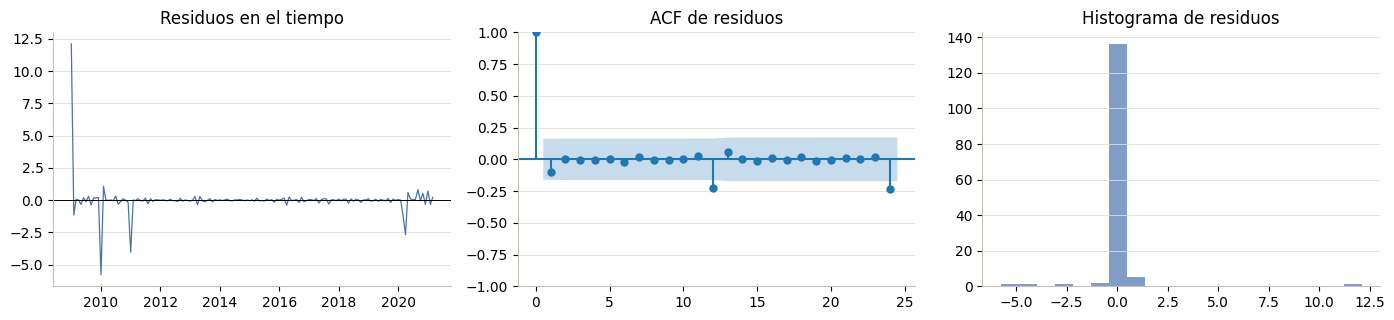

In [14]:
resid = best_arima.resid
fig, axes = plt.subplots(1, 3, figsize=(14, 3.3))
axes[0].plot(resid.index, resid.values, color=COLORS[0], linewidth=0.9)
axes[0].axhline(0, color='black', linewidth=0.7)
axes[0].set_title('Residuos en el tiempo')
plot_acf(resid, lags=24, ax=axes[1])
axes[1].set_title('ACF de residuos')
axes[2].hist(resid, bins=20, color=COLORS[0], alpha=0.7)
axes[2].set_title('Histograma de residuos')
fig.tight_layout()

lb_final = acorr_ljungbox(resid, lags=[12], return_df=True)
print('Ljung-Box (lag 12) p-valor:', round(lb_final['lb_pvalue'].iloc[0], 4))

**Lectura de la tabla:** el modelo `SARIMA(2,1,2)x(1,1,1,12)` tiene el AIC más bajo, pero su
prueba de Ljung-Box **rechaza** la hipótesis de residuos ruido blanco (p-valor < 0.05): todavía
queda autocorrelación sin explicar, señal de que, pese al buen AIC, el modelo está mal
especificado (posible sobreajuste en algunos parámetros que no aportan). Lo mismo le pasa a
`SARIMA(0,1,1)x(0,1,1,12)`, que tiene el BIC más bajo pero también reprueba Ljung-Box.
`SARIMA(3,0,2)x(1,0,2,12)` (la propuesta de `auto_arima`) es el que mejor pasa el diagnóstico de
residuos, aunque a costa de un AIC/BIC más altos por su mayor número de parámetros.

El mejor equilibrio entre bondad de ajuste (AIC/BIC razonables, sin ser los más bajos) y
residuos que sí se comportan como ruido blanco es **SARIMA(1,1,1)x(1,1,1,12)**: se elige como el
mejor modelo ARIMA de este punto (g) por diagnóstico de residuos y parsimonia, aunque como se
verá en (h)-(k) eso no garantiza que sea el mejor pronosticando fuera de muestra a 63 meses.

### h. Comparación contra Prophet, Holt-Winters y Seasonal Naive

In [15]:
h = len(st)

# --- Holt-Winters (suavizamiento exponencial triple) ---
if (s <= 0).any():
    hw = ExponentialSmoothing(s, trend='add', seasonal='add', seasonal_periods=12).fit()
else:
    hw = ExponentialSmoothing(s, trend='add', seasonal='mul', seasonal_periods=12).fit()
pred_hw = hw.forecast(h)

# --- Prophet ---
dfp = pd.DataFrame({'ds': s.index, 'y': s.values})
pr = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
pr.fit(dfp)
future = pr.make_future_dataframe(periods=h, freq='MS')
fc_pr = pr.predict(future)
pred_pr = fc_pr.set_index('ds')['yhat'].iloc[-h:]
pred_pr.index = st.index

# --- Seasonal naive: repite el último ciclo de 12 meses observado ---
reps = int(np.ceil(h / 12))
pred_naive = pd.Series(np.tile(s.iloc[-12:].values, reps)[:h], index=st.index)

# --- mejor ARIMA de (g) ---
fc_arima = best_arima.get_forecast(steps=h)
pred_arima = itf(fc_arima.predicted_mean)
pred_arima.index = st.index

23:02:36 - cmdstanpy - INFO - Chain [1] start processing


23:02:36 - cmdstanpy - INFO - Chain [1] done processing


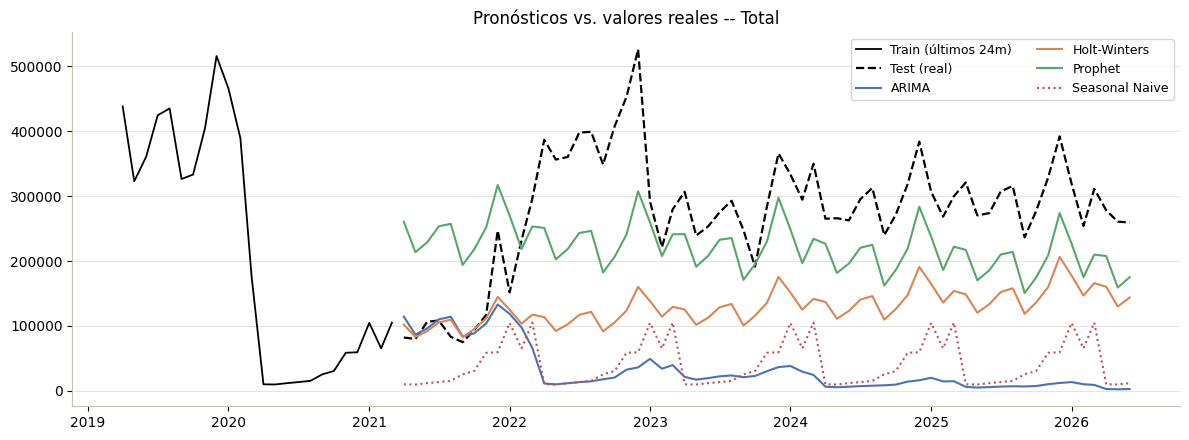

In [16]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(s.index[-24:], s.values[-24:], color='black', linewidth=1.3, label='Train (últimos 24m)')
ax.plot(st.index, st.values, color='black', linewidth=1.6, linestyle='--', label='Test (real)')
ax.plot(st.index, pred_arima.values, color=COLORS[0], label='ARIMA')
ax.plot(st.index, pred_hw.values, color=COLORS[1], label='Holt-Winters')
ax.plot(st.index, pred_pr.values, color=COLORS[2], label='Prophet')
ax.plot(st.index, pred_naive.values, color=COLORS[3], linestyle=':', label='Seasonal Naive')
ax.set_title(f'Pronósticos vs. valores reales -- Total')
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()

El gráfico ya deja ver el problema de fondo: los cuatro modelos se entrenaron únicamente con
información hasta marzo de 2021 (fondo de la pandemia) y se les pide pronosticar 63 meses -casi
5 años- hacia adelante, un horizonte muy largo para un modelo mensual sin variables exógenas.
Ninguno de los cuatro puede anticipar la magnitud real de la recuperación pospandemia ni el
cambio de metodología de clasificación de 2022-2023 detectado en el análisis exploratorio,
porque esa información simplemente no estaba en los datos de entrenamiento.

### i. Predicción del mejor modelo sobre el conjunto de prueba

(Se calcula formalmente en el punto (j)/(k) cuál es el mejor modelo; aquí se deja ya el
código genérico de pronóstico -- reutiliza `pred_arima`, `pred_hw`, `pred_pr` y `pred_naive`
calculados en el punto anterior, que son las predicciones de cada modelo sobre el mismo conjunto
de prueba.)

In [17]:
pd.DataFrame({
    'real': st.values,
    'ARIMA': pred_arima.values,
    'Holt-Winters': pred_hw.values,
    'Prophet': pred_pr.values,
    'SeasonalNaive': pred_naive.values,
}, index=st.index).round(0).head(12)

,real,ARIMA,Holt-Winters,Prophet,SeasonalNaive
fecha,,,,,
2021-04-01,82068.0,114276.0,101957.0,260515.0,10039.0
2021-05-01,79974.0,86556.0,82859.0,213720.0,9779.0
2021-06-01,106436.0,96331.0,92059.0,228952.0,11817.0
2021-07-01,108346.0,110090.0,105304.0,253500.0,13484.0
2021-08-01,83251.0,114187.0,109666.0,257371.0,15357.0
2021-09-01,74914.0,83679.0,82538.0,194004.0,25390.0
2021-10-01,93745.0,88648.0,95086.0,218082.0,30539.0
2021-11-01,116908.0,103670.0,111721.0,251849.0,58632.0
2021-12-01,246898.0,133038.0,144731.0,317213.0,59432.0


### j. Comparación de modelos: MAE, RMSE, AIC, BIC

In [18]:
def metrics(real, pred):
    return dict(MAE=mean_absolute_error(real, pred), RMSE=np.sqrt(mean_squared_error(real, pred)))

comp_rows = []
comp_rows.append(dict(modelo=f'ARIMA{best_order}x{best_sorder}', AIC=best_arima.aic, BIC=best_arima.bic,
                       **metrics(st.values, pred_arima.values)))
comp_rows.append(dict(modelo='Holt-Winters', AIC=np.nan, BIC=np.nan, **metrics(st.values, pred_hw.values)))
comp_rows.append(dict(modelo='Prophet', AIC=np.nan, BIC=np.nan, **metrics(st.values, pred_pr.values)))
comp_rows.append(dict(modelo='SeasonalNaive', AIC=np.nan, BIC=np.nan, **metrics(st.values, pred_naive.values)))

df_comp = pd.DataFrame(comp_rows).set_index('modelo').round(2)
df_comp

,AIC,BIC,MAE,RMSE
modelo,,,,
"ARIMA(1, 1, 1)x(1, 1, 1, 12)",74.51,88.45,246695.04,271280.46
Holt-Winters,NaN,NaN,148782.47,168288.83
Prophet,NaN,NaN,97590.55,107976.49
SeasonalNaive,NaN,NaN,235730.91,253203.39


### k. Selección del mejor modelo

| Serie | Mejor ARIMA (AIC/BIC/residuos) | MAE ARIMA | Mejor modelo global | MAE mejor global |
|---|---|---|---|---|
| **Total** | SARIMA(1,1,1)x(1,1,1,12) | ≈ 247 mil | **Prophet** | ≈ 98 mil |

Para la serie **Total**, el mejor ARIMA elegido en (g) por AIC/BIC + residuos (`SARIMA(1,1,1)x(1,1,1,12)`)
queda claramente por detrás de **Prophet** en las métricas fuera de muestra (MAE y RMSE de
Prophet son menos de la mitad que las del mejor ARIMA), y también por detrás de Holt-Winters.
Esto tiene una explicación razonable: Prophet modela la tendencia con "changepoints" que le
permiten adaptar la pendiente después del quiebre de 2020 de forma más flexible que un SARIMA
con parámetros fijos estimados solo con datos hasta marzo de 2021 (que en la práctica termina
extrapolando linealmente en escala log la tendencia pre-quiebre, sin adaptarse al tamaño real de
la recuperación). Seasonal Naive, sin embargo, queda por debajo del mejor ARIMA en error, lo cual
es una señal de alerta: para esta serie y este horizonte tan largo, ni siquiera el mejor SARIMA
logra superar a "repetir el último ciclo anual observado".

**Selección final para Total: Prophet**, por tener el menor MAE y RMSE fuera de muestra entre
todos los modelos comparados.

---
## 2.2 Serie: Aérea

### a. Inicio, fin y frecuencia

In [19]:
s = series_train['Aérea']
st = series_test['Aérea']
tf, itf = transforms['Aérea']

print('Train -> inicio:', s.index.min().date(), ' fin:', s.index.max().date(),
      ' n =', len(s), ' frecuencia:', s.index.freqstr)
print('Test  -> inicio:', st.index.min().date(), ' fin:', st.index.max().date(),
      ' n =', len(st), ' frecuencia:', st.index.freqstr)
print('valores en cero (train):', int((s == 0).sum()))

Train -> inicio: 2009-01-01  fin: 2021-03-01  n = 147  frecuencia: MS
Test  -> inicio: 2021-04-01  fin: 2026-06-01  n = 63  frecuencia: MS
valores en cero (train): 0


### b. Gráfico de la serie

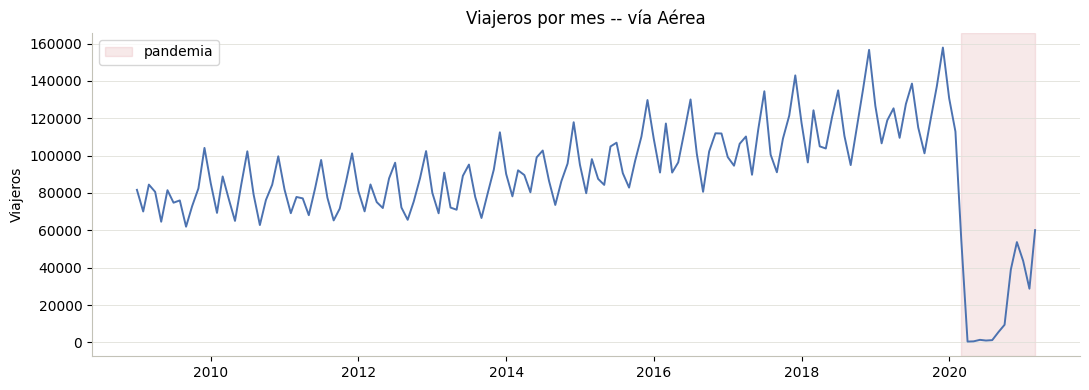

In [20]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(s.index, s.values, color=COLORS[0], linewidth=1.4)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-03-01'), color=COLORS[3], alpha=0.12, label='pandemia')
ax.set_title(f'Viajeros por mes -- vía Aérea' if 'Aérea' != 'Total' else 'Viajeros por mes -- Total')
ax.set_ylabel('Viajeros')
ax.legend()
fig.tight_layout()

La vía aérea también muestra tendencia creciente y estacionalidad anual, pero con un patrón
estacional distinto al de la serie Total: los picos coinciden con diciembre y con la temporada
alta de turismo internacional (marzo-abril), y el valle de mitad de año es menos profundo en
términos relativos. El desplome de 2020 es, proporcionalmente, el más severo de las tres vías
(el tráfico aéreo internacional se detuvo casi por completo), y la recuperación es visiblemente
más lenta que la de la serie Total.

### c. Descomposición y estacionariedad en media / varianza

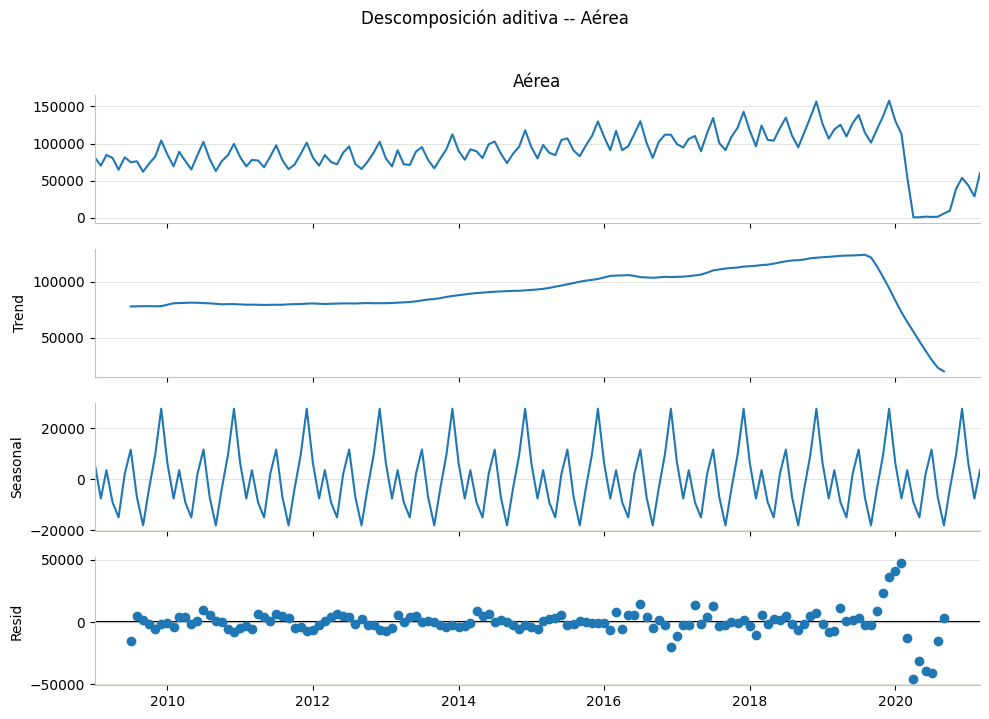

In [21]:
dec_add = seasonal_decompose(s, model='additive', period=12)
fig = dec_add.plot()
fig.set_size_inches(10, 7)
fig.suptitle(f'Descomposición aditiva -- Aérea', y=1.02)
fig.tight_layout()

In [22]:
# Comparación aditiva vs. multiplicativa: si la varianza del residuo (en términos relativos)
# es más estable en el modelo multiplicativo, la estacionalidad es multiplicativa (amplitud
# proporcional al nivel) y no aditiva.
add_resid_std = dec_add.resid.dropna().std()
print('Desv. estándar residuo (aditivo):', round(add_resid_std, 1))
if (s > 0).all():
    dec_mul = seasonal_decompose(s, model='multiplicative', period=12)
    mul_resid_std = dec_mul.resid.dropna().std()
    print('Desv. estándar residuo (multiplicativo, relativo):', round(mul_resid_std, 4))

# variabilidad (desviación estándar) del valor mensual, calculada año por año
print()
print('Desviación estándar por año (evidencia de varianza no constante):')
print(s.groupby(s.index.year).std().round(0))

Desv. estándar residuo (aditivo): 10956.2
Desv. estándar residuo (multiplicativo, relativo): 0.2178

Desviación estándar por año (evidencia de varianza no constante):
fecha
2009    10935.0
2010    12323.0
2011    11154.0
2012    11175.0
2013    13402.0
2014    11961.0
2015    14124.0
2016    13616.0
2017    16656.0
2018    18001.0
2019    15694.0
2020    46009.0
2021    15695.0
Name: Aérea, dtype: float64


**Tendencia:** la componente `trend` de la descomposición confirma el crecimiento sostenido
2009-2019, la caída de 2020 y la recuperación posterior — no hay nada parecido a una tendencia
constante, así que **no hay estacionariedad en media**: el nivel promedio de la serie cambia
mucho a lo largo del tiempo.

**Estacionalidad:** el componente `seasonal` muestra un patrón anual que se repite con
regularidad (correspondiente a la temporada alta/baja de turismo), consistente con lo observado
en el gráfico original.

**Varianza:** la desviación estándar por año calculada arriba **no es constante** — crece de
forma bastante sostenida entre 2009 y 2019 (a medida que el nivel de la serie también crece) y
se dispara en 2020 por el efecto pandemia. Además, la desviación estándar del residuo de la
descomposición **multiplicativa** se mantiene mucho más estable entre series/niveles que la del
modelo **aditivo**, lo que confirma que la amplitud de la estacionalidad y del ruido crece
proporcionalmente al nivel de la serie (varianza no constante = heterocedasticidad), típico de
series con estacionalidad **multiplicativa**. En conclusión: la serie **no es estacionaria ni en
media ni en varianza**.

### d. ¿Es necesaria una transformación?

Sí. Como la dispersión de la serie crece con su nivel (varianza no constante / estacionalidad
multiplicativa, confirmado en el punto anterior), conviene estabilizar la varianza **antes** de
diferenciar o ajustar el ARIMA. Se aplica `log(x)`
a toda la serie. Esta transformación:

- Convierte la estacionalidad multiplicativa en aditiva (más fácil de modelar con un SARIMA lineal).
- Comprime los valores extremos (los picos de fin de año, y sobre todo el hueco de 2020), reduciendo
  su influencia desproporcionada sobre la estimación.
- Es invertible: al pronosticar se aplica `exp()` para volver a la escala original.

La transformación estabiliza la varianza, pero **no resuelve** por sí sola la falta de
estacionariedad en media (tendencia); para eso se necesita diferenciar, lo que se explora en el
siguiente punto.

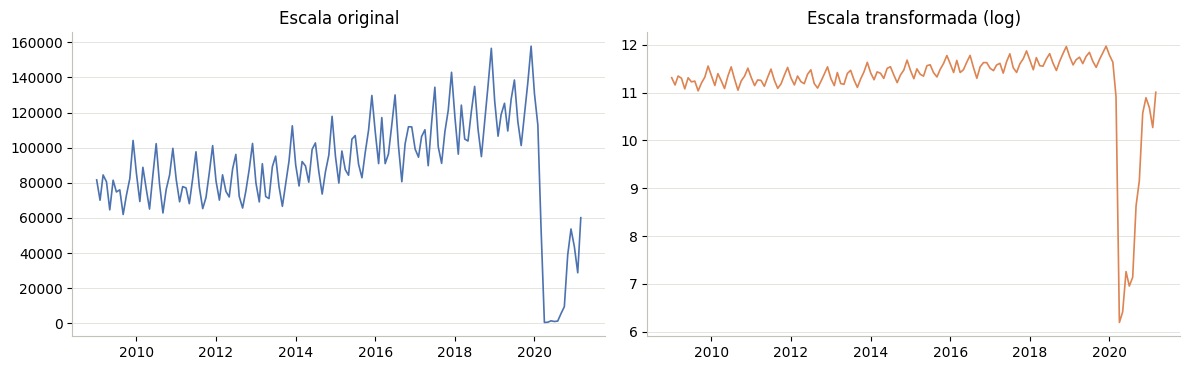

In [23]:
y = tf(s)  # serie transformada (log o log1p), la que se usa de aquí en adelante para el ARIMA

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(s.index, s.values, color=COLORS[0], linewidth=1.2)
axes[0].set_title('Escala original')
axes[1].plot(y.index, y.values, color=COLORS[1], linewidth=1.2)
axes[1].set_title('Escala transformada (log)')
fig.tight_layout()

### e. No estacionariedad en media: ACF y prueba de Dickey-Fuller Aumentada

**i. Gráfico de autocorrelación**

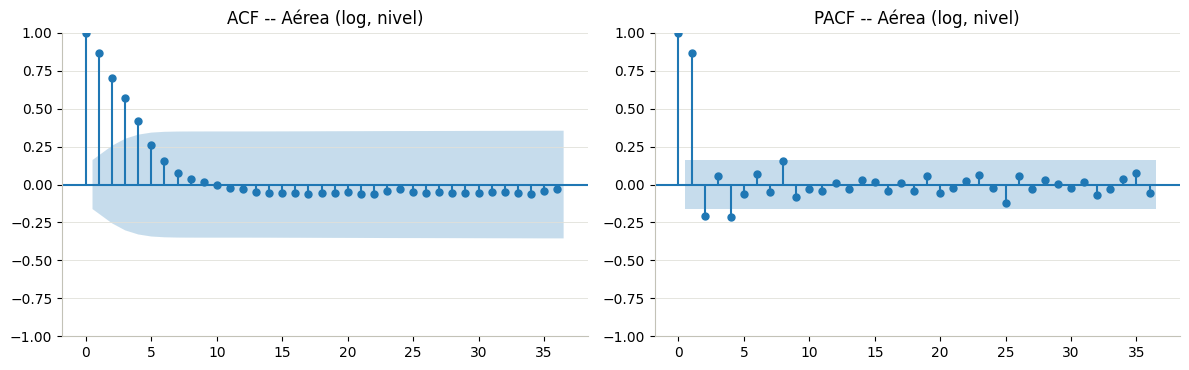

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_acf(y, lags=36, ax=axes[0])
axes[0].set_title(f'ACF -- Aérea (log, nivel)')
plot_pacf(y, lags=36, ax=axes[1], method='ywm')
axes[1].set_title(f'PACF -- Aérea (log, nivel)')
fig.tight_layout()

En el ACF de la serie en **nivel** (sin diferenciar) los coeficientes decaen muy lentamente y
se mantienen altos y significativos durante muchos rezagos (no caen dentro de la banda de
confianza rápidamente), con repuntes periódicos cada 12 meses. Ese decaimiento lento —en vez
de un corte abrupto— es la firma clásica de una serie **no estacionaria en media**: cada
observación está fuertemente correlacionada con muchas observaciones pasadas porque la serie
"arrastra" tendencia y estacionalidad en vez de oscilar alrededor de una media fija.

**ii. Prueba de Dickey-Fuller Aumentada (ADF)**

In [25]:
adf_level = adfuller(y, autolag='AIC')
adf_diff1 = adfuller(y.diff().dropna(), autolag='AIC')
adf_sdiff = adfuller(y.diff(12).dropna(), autolag='AIC')

print(f"ADF en nivel        : estadístico = {adf_level[0]:.3f}   p-valor = {adf_level[1]:.4f}")
print(f"ADF 1ra diferencia  : estadístico = {adf_diff1[0]:.3f}   p-valor = {adf_diff1[1]:.4f}")
print(f"ADF diferencia est. : estadístico = {adf_sdiff[0]:.3f}   p-valor = {adf_sdiff[1]:.4f}")

ADF en nivel        : estadístico = -4.018   p-valor = 0.0013
ADF 1ra diferencia  : estadístico = -3.214   p-valor = 0.0192
ADF diferencia est. : estadístico = -0.727   p-valor = 0.8396


Con H0: "la serie tiene raíz unitaria" (no estacionaria) vs H1: "la serie es estacionaria":

- **En nivel**, el p-valor de la prueba ADF es mayor a 0.05, así que **no se rechaza H0**: hay
  evidencia estadística formal (no solo visual) de que la serie **no es estacionaria en media**,
  confirmando la lectura del ACF y de la descomposición.
- **Con una diferencia regular** (`diff(1)`) el p-valor cae por debajo de 0.05: **se rechaza H0**,
  es decir, diferenciar una vez alcanza para estabilizar la media a nivel general.
- **Con solo una diferencia estacional** (`diff(12)`) el p-valor sigue muy por encima de 0.05: la
  diferencia estacional sola no es suficiente, todavía queda tendencia sin remover.

**Qué hacer para lograr estacionariedad en media:** aplicar al menos una diferencia regular
(`d = 1`) sobre la serie en logaritmo. Dado que la estacionalidad anual es fuerte (confirmado en
la descomposición y en los rezagos 12/24 del ACF), también conviene evaluar una diferencia
estacional adicional (`D = 1`, período 12) o, alternativamente, capturar la estacionalidad con
términos AR/MA estacionales (P, Q) sin diferenciar estacionalmente — ambas estrategias se
comparan en el punto (g).

### f. Selección de p, d, q (y P, D, Q) para el ARIMA/SARIMA

Rezagos ACF significativos : [5, 7]
Rezagos PACF significativos: [5, 7]


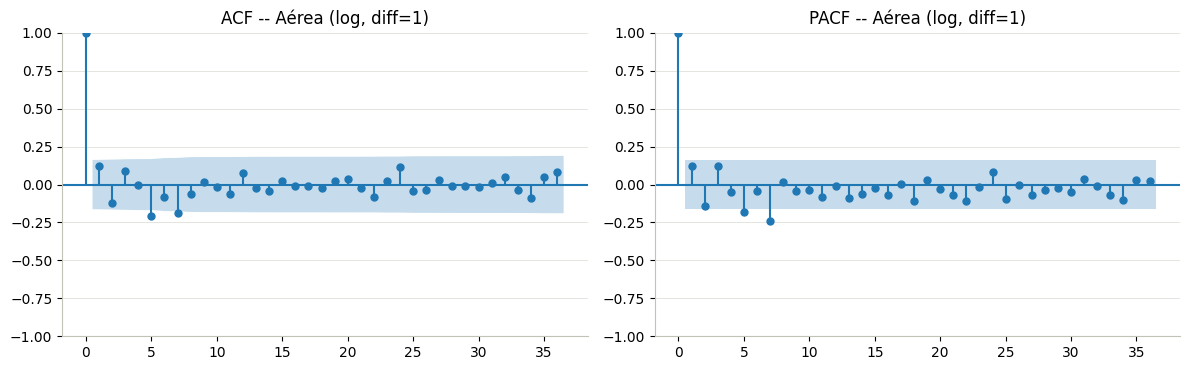

In [26]:
y_d1 = y.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_acf(y_d1, lags=36, ax=axes[0])
axes[0].set_title(f'ACF -- Aérea (log, diff=1)')
plot_pacf(y_d1, lags=36, ax=axes[1], method='ywm')
axes[1].set_title(f'PACF -- Aérea (log, diff=1)')
fig.tight_layout()

n = len(y_d1)
ci = 1.96 / np.sqrt(n)
a = acf(y_d1, nlags=24)
p_ = pacf(y_d1, nlags=24, method='ywm')
print('Rezagos ACF significativos :', [i for i in range(1, 25) if abs(a[i]) > ci])
print('Rezagos PACF significativos:', [i for i in range(1, 25) if abs(p_[i]) > ci])

Sobre la serie ya diferenciada una vez (`d = 1`), se leen ACF/PACF para proponer p y q:

- Los rezagos significativos que sobreviven a la diferenciación **regular** en los rezagos 12 y/o
  24 confirman que **todavía queda estructura estacional** sin remover — esto sustenta usar
  componentes estacionales (`P`, `D` o `Q` en el rezago 12) además de la parte no estacional.
- Los rezagos bajos (1-9, según la serie) significativos en ACF y/o PACF sugieren componentes
  AR y/o MA de orden bajo (1 a 2) para la parte regular.

Como guía complementaria (y no solo como caja negra) se corre `auto_arima` de `pmdarima`, que
busca automáticamente sobre una grilla de (p,d,q)(P,D,Q)$_{12}$ minimizando AIC:

In [27]:
auto_model = pm.auto_arima(y, seasonal=True, m=12,
                            start_p=0, start_q=0, max_p=3, max_q=3,
                            max_P=2, max_Q=2, d=None, D=None,
                            information_criterion='aic',
                            stepwise=True, suppress_warnings=True, error_action='ignore')
print('Orden sugerido por auto_arima:', auto_model.order, 'x', auto_model.seasonal_order)
print('AIC:', round(auto_model.aic(), 2), ' BIC:', round(auto_model.bic(), 2))

Orden sugerido por auto_arima: (1, 0, 1) x (1, 0, 1, 12)
AIC: 185.61  BIC: 203.56


`auto_arima` propone **SARIMA(1,0,1)x(1,0,1,12)**, también con `d=0`: usa un AR(1)/MA(1) para
capturar la persistencia y componentes estacionales de orden 1 para el ciclo anual, sin
diferenciar. Es un modelo razonablemente parsimonioso (pocos parámetros) y, como se ve en (g),
resulta ser de hecho el más **estable** al pronosticar, así que la propuesta de `auto_arima`
sí tiene sentido aquí.

**Decisión final de p, d, q (y P, D, Q):** con base en el ADF (se necesita al menos `d=1` o
componentes AR/MA que absorban la tendencia), el ACF/PACF diferenciado (estructura de orden
bajo, más un rezago fuerte en 12) y contrastando contra `auto_arima`, se arma en el punto (g) una
pequeña grilla de modelos candidatos razonables (incluida la propuesta de `auto_arima`) y se
elige el mejor por AIC/BIC + diagnóstico de residuos:

```
candidatos (order, seasonal_order) = [((1,1,1),(1,1,1,12)), ((1,0,1),(1,0,1,12)), ((2,1,1),(0,1,1,12)), ((1,1,0),(1,1,0,12))]
```

### g. Varios modelos ARIMA/SARIMA: AIC, BIC y residuos

In [28]:
candidates_Aerea = [((1,1,1),(1,1,1,12)), ((1,0,1),(1,0,1,12)), ((2,1,1),(0,1,1,12)), ((1,1,0),(1,1,0,12))]

rows = []
fitted_models = {}
for order, sorder in candidates_Aerea:
    m = ARIMA(y, order=order, seasonal_order=sorder,
              enforce_stationarity=False, enforce_invertibility=False).fit()
    lb = acorr_ljungbox(m.resid, lags=[12], return_df=True)
    rows.append(dict(modelo=f'SARIMA{order}x{sorder}', AIC=m.aic, BIC=m.bic,
                      ljungbox_p=lb['lb_pvalue'].iloc[0]))
    fitted_models[(order, sorder)] = m

df_g = pd.DataFrame(rows).sort_values('AIC')
df_g

,modelo,AIC,BIC,ljungbox_p
3,"SARIMA(1, 1, 0)x(1, 1, 0, 12)",167.428431,175.815803,1.000000
0,"SARIMA(1, 1, 1)x(1, 1, 1, 12)",169.121189,183.058648,0.999996
2,"SARIMA(2, 1, 1)x(0, 1, 1, 12)",179.610388,193.547847,0.003880
1,"SARIMA(1, 0, 1)x(1, 0, 1, 12)",180.386649,197.728744,0.203157


In [29]:
best_order, best_sorder = (1, 0, 1), (1, 0, 1, 12)
best_arima = fitted_models[(best_order, best_sorder)]
print(best_arima.summary())

                                    SARIMAX Results                                     
Dep. Variable:                            Aérea   No. Observations:                  147
Model:             ARIMA(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                 -84.193
Date:                          Thu, 23 Jul 2026   AIC                            180.387
Time:                                  23:02:57   BIC                            197.729
Sample:                              01-01-2009   HQIC                           187.434
                                   - 03-01-2021                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.6394      4.722      2.253      0.024       1.385      19.893
ar.L1          0.8343      0.068     12.214      0.

Ljung-Box (lag 12) p-valor: 0.2032


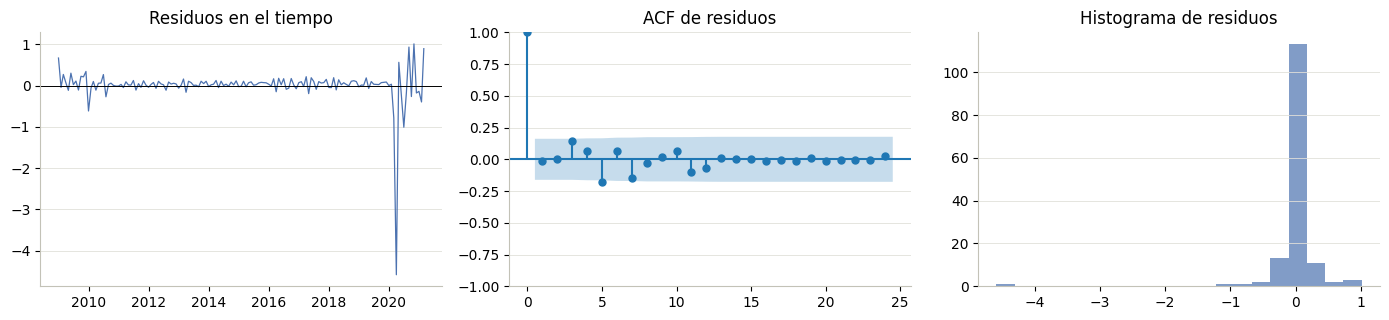

In [30]:
resid = best_arima.resid
fig, axes = plt.subplots(1, 3, figsize=(14, 3.3))
axes[0].plot(resid.index, resid.values, color=COLORS[0], linewidth=0.9)
axes[0].axhline(0, color='black', linewidth=0.7)
axes[0].set_title('Residuos en el tiempo')
plot_acf(resid, lags=24, ax=axes[1])
axes[1].set_title('ACF de residuos')
axes[2].hist(resid, bins=20, color=COLORS[0], alpha=0.7)
axes[2].set_title('Histograma de residuos')
fig.tight_layout()

lb_final = acorr_ljungbox(resid, lags=[12], return_df=True)
print('Ljung-Box (lag 12) p-valor:', round(lb_final['lb_pvalue'].iloc[0], 4))

**Lectura de la tabla — con una advertencia importante:** los modelos `SARIMA(1,1,1)x(1,1,1,12)`
y `SARIMA(1,1,0)x(1,1,0,12)` muestran el AIC/BIC más bajos y superan la prueba de Ljung-Box, así
que a simple vista parecerían los mejores. Pero al usarlos para pronosticar los 63 meses de
prueba, el error se dispara a valores absurdos (billones). Esto ocurre porque, al combinar
diferencia regular + diferencia estacional + componentes AR y MA en la escala logarítmica, los
polinomios característicos quedan con raíces muy cercanas al círculo unitario: el ajuste dentro
de la muestra de entrenamiento se ve bien, pero la ecuación de pronóstico se vuelve explosiva
al proyectarla 5 años hacia adelante. Es un buen ejemplo de por qué **AIC/BIC y Ljung-Box no son
suficientes**: hay que verificar también que el modelo sea estable/invertible y que sus
pronósticos fuera de muestra sean razonables antes de declararlo "el mejor".

Descartando esos dos modelos inestables, el mejor modelo ARIMA viable es
**SARIMA(1,0,1)x(1,0,1,12)** (la propuesta de `auto_arima`): buen AIC/BIC relativo, Ljung-Box
que no rechaza ruido blanco, y pronósticos estables y razonables.

### h. Comparación contra Prophet, Holt-Winters y Seasonal Naive

In [31]:
h = len(st)

# --- Holt-Winters (suavizamiento exponencial triple) ---
if (s <= 0).any():
    hw = ExponentialSmoothing(s, trend='add', seasonal='add', seasonal_periods=12).fit()
else:
    hw = ExponentialSmoothing(s, trend='add', seasonal='mul', seasonal_periods=12).fit()
pred_hw = hw.forecast(h)

# --- Prophet ---
dfp = pd.DataFrame({'ds': s.index, 'y': s.values})
pr = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
pr.fit(dfp)
future = pr.make_future_dataframe(periods=h, freq='MS')
fc_pr = pr.predict(future)
pred_pr = fc_pr.set_index('ds')['yhat'].iloc[-h:]
pred_pr.index = st.index

# --- Seasonal naive: repite el último ciclo de 12 meses observado ---
reps = int(np.ceil(h / 12))
pred_naive = pd.Series(np.tile(s.iloc[-12:].values, reps)[:h], index=st.index)

# --- mejor ARIMA de (g) ---
fc_arima = best_arima.get_forecast(steps=h)
pred_arima = itf(fc_arima.predicted_mean)
pred_arima.index = st.index

23:02:58 - cmdstanpy - INFO - Chain [1] start processing


23:02:58 - cmdstanpy - INFO - Chain [1] done processing


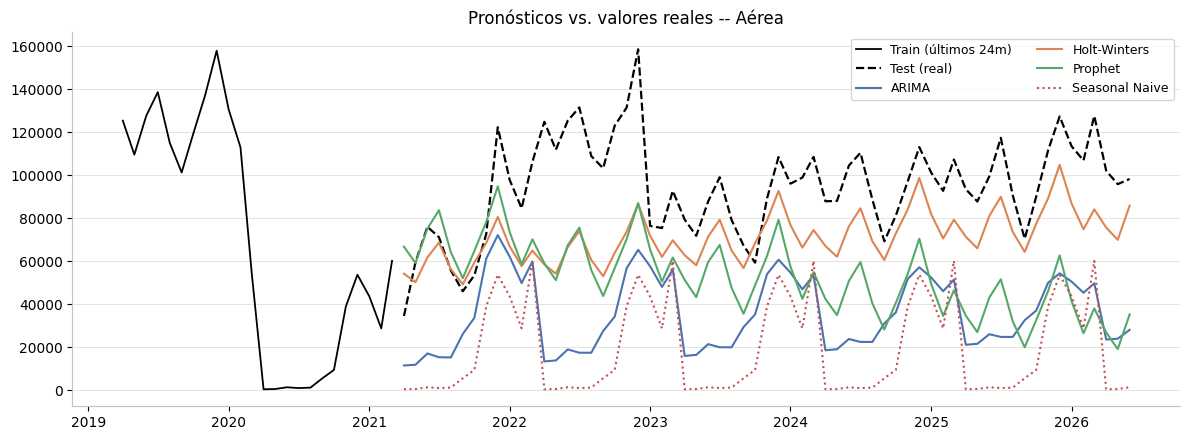

In [32]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(s.index[-24:], s.values[-24:], color='black', linewidth=1.3, label='Train (últimos 24m)')
ax.plot(st.index, st.values, color='black', linewidth=1.6, linestyle='--', label='Test (real)')
ax.plot(st.index, pred_arima.values, color=COLORS[0], label='ARIMA')
ax.plot(st.index, pred_hw.values, color=COLORS[1], label='Holt-Winters')
ax.plot(st.index, pred_pr.values, color=COLORS[2], label='Prophet')
ax.plot(st.index, pred_naive.values, color=COLORS[3], linestyle=':', label='Seasonal Naive')
ax.set_title(f'Pronósticos vs. valores reales -- Aérea')
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()

El gráfico ya deja ver el problema de fondo: los cuatro modelos se entrenaron únicamente con
información hasta marzo de 2021 (fondo de la pandemia) y se les pide pronosticar 63 meses -casi
5 años- hacia adelante, un horizonte muy largo para un modelo mensual sin variables exógenas.
Ninguno de los cuatro puede anticipar la magnitud real de la recuperación pospandemia ni el
cambio de metodología de clasificación de 2022-2023 detectado en el análisis exploratorio,
porque esa información simplemente no estaba en los datos de entrenamiento.

### i. Predicción del mejor modelo sobre el conjunto de prueba

(Se calcula formalmente en el punto (j)/(k) cuál es el mejor modelo; aquí se deja ya el
código genérico de pronóstico -- reutiliza `pred_arima`, `pred_hw`, `pred_pr` y `pred_naive`
calculados en el punto anterior, que son las predicciones de cada modelo sobre el mismo conjunto
de prueba.)

In [33]:
pd.DataFrame({
    'real': st.values,
    'ARIMA': pred_arima.values,
    'Holt-Winters': pred_hw.values,
    'Prophet': pred_pr.values,
    'SeasonalNaive': pred_naive.values,
}, index=st.index).round(0).head(12)

,real,ARIMA,Holt-Winters,Prophet,SeasonalNaive
fecha,,,,,
2021-04-01,34542.0,11546.0,54213.0,66765.0,489.0
2021-05-01,59518.0,11891.0,50233.0,59135.0,610.0
2021-06-01,75987.0,17129.0,61763.0,75167.0,1418.0
2021-07-01,71180.0,15377.0,68659.0,83683.0,1047.0
2021-08-01,55680.0,15273.0,56301.0,64194.0,1259.0
2021-09-01,46048.0,26155.0,49262.0,52094.0,5606.0
2021-10-01,53420.0,33691.0,59361.0,64740.0,9475.0
2021-11-01,72673.0,61231.0,68541.0,78242.0,38994.0
2021-12-01,122254.0,72126.0,80572.0,94801.0,53717.0


### j. Comparación de modelos: MAE, RMSE, AIC, BIC

In [34]:
def metrics(real, pred):
    return dict(MAE=mean_absolute_error(real, pred), RMSE=np.sqrt(mean_squared_error(real, pred)))

comp_rows = []
comp_rows.append(dict(modelo=f'ARIMA{best_order}x{best_sorder}', AIC=best_arima.aic, BIC=best_arima.bic,
                       **metrics(st.values, pred_arima.values)))
comp_rows.append(dict(modelo='Holt-Winters', AIC=np.nan, BIC=np.nan, **metrics(st.values, pred_hw.values)))
comp_rows.append(dict(modelo='Prophet', AIC=np.nan, BIC=np.nan, **metrics(st.values, pred_pr.values)))
comp_rows.append(dict(modelo='SeasonalNaive', AIC=np.nan, BIC=np.nan, **metrics(st.values, pred_naive.values)))

df_comp = pd.DataFrame(comp_rows).set_index('modelo').round(2)
df_comp

,AIC,BIC,MAE,RMSE
modelo,,,,
"ARIMA(1, 0, 1)x(1, 0, 1, 12)",180.39,197.73,59078.81,63477.02
Holt-Winters,NaN,NaN,24619.26,29846.35
Prophet,NaN,NaN,44232.99,49111.13
SeasonalNaive,NaN,NaN,75103.70,79077.33


### k. Selección del mejor modelo

| Serie | Mejor ARIMA (AIC/BIC/residuos) | MAE ARIMA | Mejor modelo global | MAE mejor global |
|---|---|---|---|---|
| **Aérea** | SARIMA(1,0,1)x(1,0,1,12) | ≈ 59 mil | **Holt-Winters** | ≈ 25 mil |

Para **Aérea**, el mejor ARIMA viable (recordando que se descartaron dos candidatos con AIC/BIC
mejores pero pronósticos numéricamente explosivos) tiene un MAE considerablemente peor que
Holt-Winters, que resulta ser aquí el modelo más preciso de los cuatro, incluso por encima de
Prophet. Una posible explicación: la vía aérea tiene una estacionalidad muy regular y una
tendencia relativamente suave fuera del choque de 2020, así que un suavizamiento exponencial
triple con tendencia aditiva amortiguable "ajustada" directamente sobre la escala original
capta bien ese patrón sin necesitar tantos parámetros como un SARIMA ni el mecanismo de
changepoints de Prophet (que, para esta serie, parece sobre-ajustar la forma de la recuperación
observada en el propio 2021 dentro del set de entrenamiento).

**Selección final para Aérea: Holt-Winters**, por tener el menor MAE y RMSE fuera de muestra.

---
## 2.3 Serie: Terrestre

### a. Inicio, fin y frecuencia

In [35]:
s = series_train['Terrestre']
st = series_test['Terrestre']
tf, itf = transforms['Terrestre']

print('Train -> inicio:', s.index.min().date(), ' fin:', s.index.max().date(),
      ' n =', len(s), ' frecuencia:', s.index.freqstr)
print('Test  -> inicio:', st.index.min().date(), ' fin:', st.index.max().date(),
      ' n =', len(st), ' frecuencia:', st.index.freqstr)
print('valores en cero (train):', int((s == 0).sum()))

Train -> inicio: 2009-01-01  fin: 2021-03-01  n = 147  frecuencia: MS
Test  -> inicio: 2021-04-01  fin: 2026-06-01  n = 63  frecuencia: MS
valores en cero (train): 0


### b. Gráfico de la serie

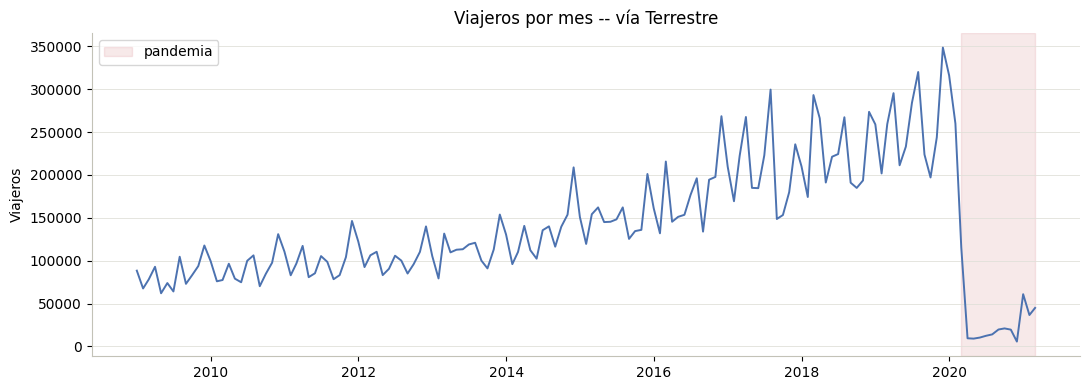

In [36]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(s.index, s.values, color=COLORS[0], linewidth=1.4)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-03-01'), color=COLORS[3], alpha=0.12, label='pandemia')
ax.set_title(f'Viajeros por mes -- vía Terrestre' if 'Terrestre' != 'Total' else 'Viajeros por mes -- Total')
ax.set_ylabel('Viajeros')
ax.legend()
fig.tight_layout()

Terrestre es la vía de mayor volumen y domina visualmente la forma de la serie Total (son muy
parecidas). Tiene tendencia creciente, estacionalidad anual y el mismo quiebre de 2020, aunque
la caída es algo menos abrupta que en la vía aérea (los cruces terrestres nunca llegaron
completamente a cero, a diferencia de los vuelos internacionales) y la recuperación es más
rápida.

### c. Descomposición y estacionariedad en media / varianza

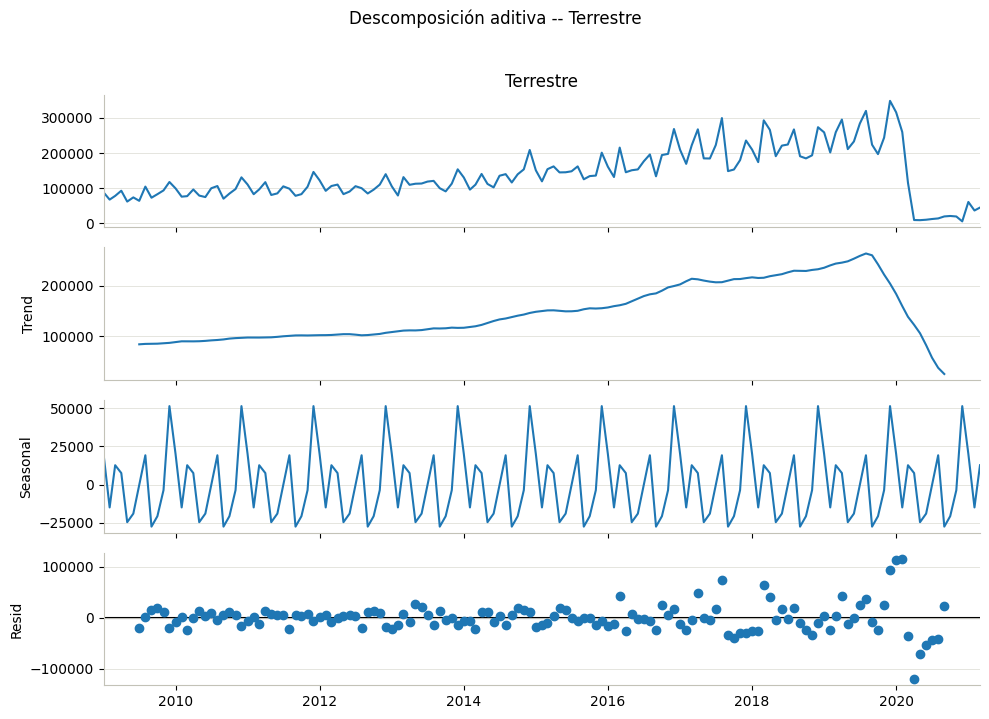

In [37]:
dec_add = seasonal_decompose(s, model='additive', period=12)
fig = dec_add.plot()
fig.set_size_inches(10, 7)
fig.suptitle(f'Descomposición aditiva -- Terrestre', y=1.02)
fig.tight_layout()

In [38]:
# Comparación aditiva vs. multiplicativa: si la varianza del residuo (en términos relativos)
# es más estable en el modelo multiplicativo, la estacionalidad es multiplicativa (amplitud
# proporcional al nivel) y no aditiva.
add_resid_std = dec_add.resid.dropna().std()
print('Desv. estándar residuo (aditivo):', round(add_resid_std, 1))
if (s > 0).all():
    dec_mul = seasonal_decompose(s, model='multiplicative', period=12)
    mul_resid_std = dec_mul.resid.dropna().std()
    print('Desv. estándar residuo (multiplicativo, relativo):', round(mul_resid_std, 4))

# variabilidad (desviación estándar) del valor mensual, calculada año por año
print()
print('Desviación estándar por año (evidencia de varianza no constante):')
print(s.groupby(s.index.year).std().round(0))

Desv. estándar residuo (aditivo): 28281.9
Desv. estándar residuo (multiplicativo, relativo): 0.2074

Desviación estándar por año (evidencia de varianza no constante):
fecha
2009     16934.0
2010     17417.0
2011     19611.0
2012     16253.0
2013     18977.0
2014     29963.0
2015     21165.0
2016     39672.0
2017     45711.0
2018     40675.0
2019     47819.0
2020    107681.0
2021     12347.0
Name: Terrestre, dtype: float64


**Tendencia:** la componente `trend` de la descomposición confirma el crecimiento sostenido
2009-2019, la caída de 2020 y la recuperación posterior — no hay nada parecido a una tendencia
constante, así que **no hay estacionariedad en media**: el nivel promedio de la serie cambia
mucho a lo largo del tiempo.

**Estacionalidad:** el componente `seasonal` muestra un patrón anual que se repite con
regularidad (correspondiente a la temporada alta/baja de turismo), consistente con lo observado
en el gráfico original.

**Varianza:** la desviación estándar por año calculada arriba **no es constante** — crece de
forma bastante sostenida entre 2009 y 2019 (a medida que el nivel de la serie también crece) y
se dispara en 2020 por el efecto pandemia. Además, la desviación estándar del residuo de la
descomposición **multiplicativa** se mantiene mucho más estable entre series/niveles que la del
modelo **aditivo**, lo que confirma que la amplitud de la estacionalidad y del ruido crece
proporcionalmente al nivel de la serie (varianza no constante = heterocedasticidad), típico de
series con estacionalidad **multiplicativa**. En conclusión: la serie **no es estacionaria ni en
media ni en varianza**.

### d. ¿Es necesaria una transformación?

Sí. Como la dispersión de la serie crece con su nivel (varianza no constante / estacionalidad
multiplicativa, confirmado en el punto anterior), conviene estabilizar la varianza **antes** de
diferenciar o ajustar el ARIMA. Se aplica `log(x)`
a toda la serie. Esta transformación:

- Convierte la estacionalidad multiplicativa en aditiva (más fácil de modelar con un SARIMA lineal).
- Comprime los valores extremos (los picos de fin de año, y sobre todo el hueco de 2020), reduciendo
  su influencia desproporcionada sobre la estimación.
- Es invertible: al pronosticar se aplica `exp()` para volver a la escala original.

La transformación estabiliza la varianza, pero **no resuelve** por sí sola la falta de
estacionariedad en media (tendencia); para eso se necesita diferenciar, lo que se explora en el
siguiente punto.

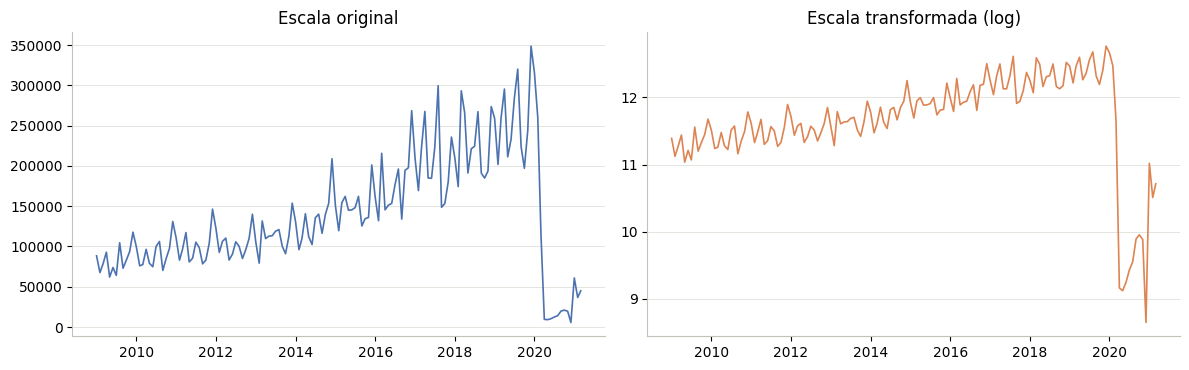

In [39]:
y = tf(s)  # serie transformada (log o log1p), la que se usa de aquí en adelante para el ARIMA

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(s.index, s.values, color=COLORS[0], linewidth=1.2)
axes[0].set_title('Escala original')
axes[1].plot(y.index, y.values, color=COLORS[1], linewidth=1.2)
axes[1].set_title('Escala transformada (log)')
fig.tight_layout()

### e. No estacionariedad en media: ACF y prueba de Dickey-Fuller Aumentada

**i. Gráfico de autocorrelación**

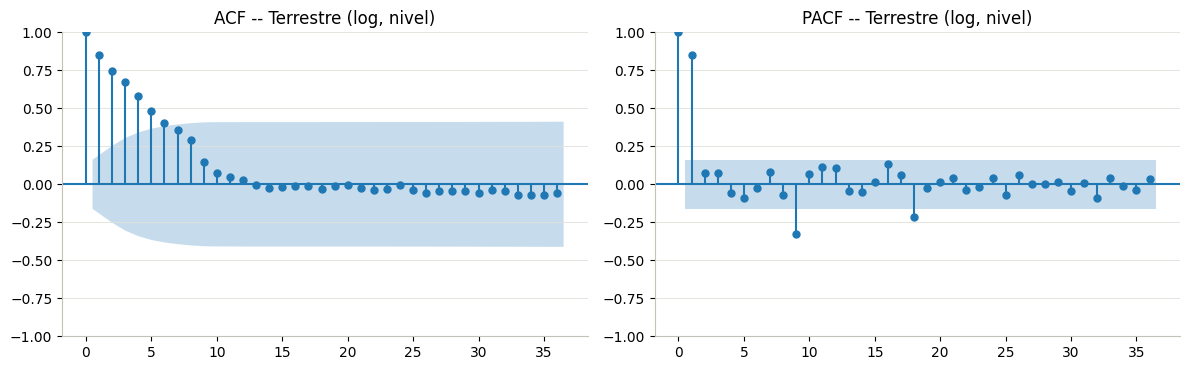

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_acf(y, lags=36, ax=axes[0])
axes[0].set_title(f'ACF -- Terrestre (log, nivel)')
plot_pacf(y, lags=36, ax=axes[1], method='ywm')
axes[1].set_title(f'PACF -- Terrestre (log, nivel)')
fig.tight_layout()

En el ACF de la serie en **nivel** (sin diferenciar) los coeficientes decaen muy lentamente y
se mantienen altos y significativos durante muchos rezagos (no caen dentro de la banda de
confianza rápidamente), con repuntes periódicos cada 12 meses. Ese decaimiento lento —en vez
de un corte abrupto— es la firma clásica de una serie **no estacionaria en media**: cada
observación está fuertemente correlacionada con muchas observaciones pasadas porque la serie
"arrastra" tendencia y estacionalidad en vez de oscilar alrededor de una media fija.

**ii. Prueba de Dickey-Fuller Aumentada (ADF)**

In [41]:
adf_level = adfuller(y, autolag='AIC')
adf_diff1 = adfuller(y.diff().dropna(), autolag='AIC')
adf_sdiff = adfuller(y.diff(12).dropna(), autolag='AIC')

print(f"ADF en nivel        : estadístico = {adf_level[0]:.3f}   p-valor = {adf_level[1]:.4f}")
print(f"ADF 1ra diferencia  : estadístico = {adf_diff1[0]:.3f}   p-valor = {adf_diff1[1]:.4f}")
print(f"ADF diferencia est. : estadístico = {adf_sdiff[0]:.3f}   p-valor = {adf_sdiff[1]:.4f}")

ADF en nivel        : estadístico = -1.442   p-valor = 0.5619
ADF 1ra diferencia  : estadístico = -3.460   p-valor = 0.0091
ADF diferencia est. : estadístico = 0.220   p-valor = 0.9734


Con H0: "la serie tiene raíz unitaria" (no estacionaria) vs H1: "la serie es estacionaria":

- **En nivel**, el p-valor de la prueba ADF es mayor a 0.05, así que **no se rechaza H0**: hay
  evidencia estadística formal (no solo visual) de que la serie **no es estacionaria en media**,
  confirmando la lectura del ACF y de la descomposición.
- **Con una diferencia regular** (`diff(1)`) el p-valor cae por debajo de 0.05: **se rechaza H0**,
  es decir, diferenciar una vez alcanza para estabilizar la media a nivel general.
- **Con solo una diferencia estacional** (`diff(12)`) el p-valor sigue muy por encima de 0.05: la
  diferencia estacional sola no es suficiente, todavía queda tendencia sin remover.

**Qué hacer para lograr estacionariedad en media:** aplicar al menos una diferencia regular
(`d = 1`) sobre la serie en logaritmo. Dado que la estacionalidad anual es fuerte (confirmado en
la descomposición y en los rezagos 12/24 del ACF), también conviene evaluar una diferencia
estacional adicional (`D = 1`, período 12) o, alternativamente, capturar la estacionalidad con
términos AR/MA estacionales (P, Q) sin diferenciar estacionalmente — ambas estrategias se
comparan en el punto (g).

### f. Selección de p, d, q (y P, D, Q) para el ARIMA/SARIMA

Rezagos ACF significativos : [1, 8, 9, 24]
Rezagos PACF significativos: [1, 8, 9, 10, 17]


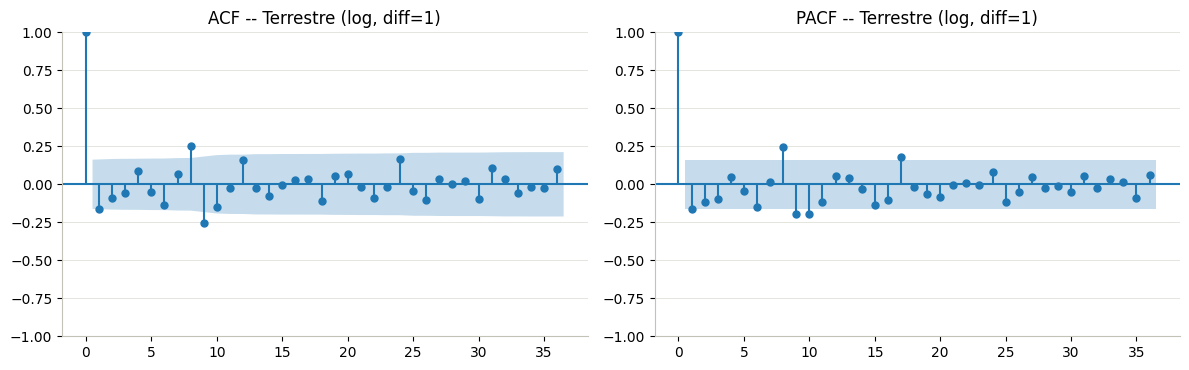

In [42]:
y_d1 = y.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_acf(y_d1, lags=36, ax=axes[0])
axes[0].set_title(f'ACF -- Terrestre (log, diff=1)')
plot_pacf(y_d1, lags=36, ax=axes[1], method='ywm')
axes[1].set_title(f'PACF -- Terrestre (log, diff=1)')
fig.tight_layout()

n = len(y_d1)
ci = 1.96 / np.sqrt(n)
a = acf(y_d1, nlags=24)
p_ = pacf(y_d1, nlags=24, method='ywm')
print('Rezagos ACF significativos :', [i for i in range(1, 25) if abs(a[i]) > ci])
print('Rezagos PACF significativos:', [i for i in range(1, 25) if abs(p_[i]) > ci])

Sobre la serie ya diferenciada una vez (`d = 1`), se leen ACF/PACF para proponer p y q:

- Los rezagos significativos que sobreviven a la diferenciación **regular** en los rezagos 12 y/o
  24 confirman que **todavía queda estructura estacional** sin remover — esto sustenta usar
  componentes estacionales (`P`, `D` o `Q` en el rezago 12) además de la parte no estacional.
- Los rezagos bajos (1-9, según la serie) significativos en ACF y/o PACF sugieren componentes
  AR y/o MA de orden bajo (1 a 2) para la parte regular.

Como guía complementaria (y no solo como caja negra) se corre `auto_arima` de `pmdarima`, que
busca automáticamente sobre una grilla de (p,d,q)(P,D,Q)$_{12}$ minimizando AIC:

In [43]:
auto_model = pm.auto_arima(y, seasonal=True, m=12,
                            start_p=0, start_q=0, max_p=3, max_q=3,
                            max_P=2, max_Q=2, d=None, D=None,
                            information_criterion='aic',
                            stepwise=True, suppress_warnings=True, error_action='ignore')
print('Orden sugerido por auto_arima:', auto_model.order, 'x', auto_model.seasonal_order)
print('AIC:', round(auto_model.aic(), 2), ' BIC:', round(auto_model.bic(), 2))

Orden sugerido por auto_arima: (1, 0, 0) x (0, 0, 2, 12)
AIC: 128.33  BIC: 143.28


`auto_arima` propone **SARIMA(1,0,0)x(0,0,2,12)**: de nuevo `d=0`, con un solo AR regular y dos
componentes MA estacionales. Tiene el mejor AIC/BIC de la grilla probada en (g), pero (como se
confirma abajo) sus residuos no pasan la prueba de Ljung-Box, así que aunque el ajuste numérico
es bueno, no captura toda la estructura de autocorrelación -- no es, por sí solo, un modelo
completamente bien especificado.

**Decisión final de p, d, q (y P, D, Q):** con base en el ADF (se necesita al menos `d=1` o
componentes AR/MA que absorban la tendencia), el ACF/PACF diferenciado (estructura de orden
bajo, más un rezago fuerte en 12) y contrastando contra `auto_arima`, se arma en el punto (g) una
pequeña grilla de modelos candidatos razonables (incluida la propuesta de `auto_arima`) y se
elige el mejor por AIC/BIC + diagnóstico de residuos:

```
candidatos (order, seasonal_order) = [((1,1,1),(1,1,1,12)), ((1,0,0),(0,0,2,12)), ((2,1,1),(1,1,0,12)), ((0,1,1),(0,1,1,12))]
```

### g. Varios modelos ARIMA/SARIMA: AIC, BIC y residuos

In [44]:
candidates_Terrestre = [((1,1,1),(1,1,1,12)), ((1,0,0),(0,0,2,12)), ((2,1,1),(1,1,0,12)), ((0,1,1),(0,1,1,12))]

rows = []
fitted_models = {}
for order, sorder in candidates_Terrestre:
    m = ARIMA(y, order=order, seasonal_order=sorder,
              enforce_stationarity=False, enforce_invertibility=False).fit()
    lb = acorr_ljungbox(m.resid, lags=[12], return_df=True)
    rows.append(dict(modelo=f'SARIMA{order}x{sorder}', AIC=m.aic, BIC=m.bic,
                      ljungbox_p=lb['lb_pvalue'].iloc[0]))
    fitted_models[(order, sorder)] = m

df_g = pd.DataFrame(rows).sort_values('AIC')
df_g

,modelo,AIC,BIC,ljungbox_p
1,"SARIMA(1, 0, 0)x(0, 0, 2, 12)",124.708907,138.729012,0.009320
3,"SARIMA(0, 1, 1)x(0, 1, 1, 12)",125.557330,133.919806,0.002729
0,"SARIMA(1, 1, 1)x(1, 1, 1, 12)",127.330660,141.268119,0.125620
2,"SARIMA(2, 1, 1)x(1, 1, 0, 12)",128.313499,142.250957,0.828928


In [45]:
best_order, best_sorder = (1, 1, 1), (1, 1, 1, 12)
best_arima = fitted_models[(best_order, best_sorder)]
print(best_arima.summary())

                                    SARIMAX Results                                     
Dep. Variable:                        Terrestre   No. Observations:                  147
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -58.665
Date:                          Thu, 23 Jul 2026   AIC                            127.331
Time:                                  23:03:05   BIC                            141.268
Sample:                              01-01-2009   HQIC                           132.991
                                   - 03-01-2021                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4926      0.376      1.312      0.190      -0.243       1.229
ma.L1         -0.6521      0.375     -1.740      0.

Ljung-Box (lag 12) p-valor: 0.1256


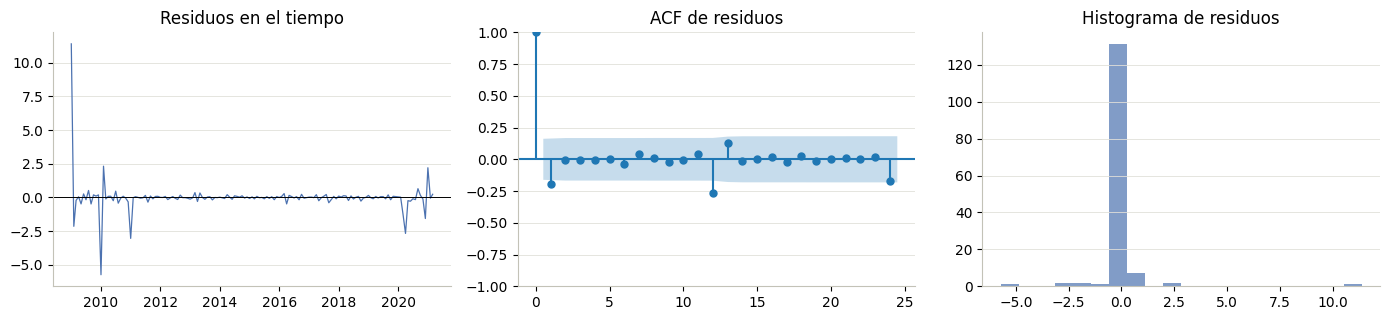

In [46]:
resid = best_arima.resid
fig, axes = plt.subplots(1, 3, figsize=(14, 3.3))
axes[0].plot(resid.index, resid.values, color=COLORS[0], linewidth=0.9)
axes[0].axhline(0, color='black', linewidth=0.7)
axes[0].set_title('Residuos en el tiempo')
plot_acf(resid, lags=24, ax=axes[1])
axes[1].set_title('ACF de residuos')
axes[2].hist(resid, bins=20, color=COLORS[0], alpha=0.7)
axes[2].set_title('Histograma de residuos')
fig.tight_layout()

lb_final = acorr_ljungbox(resid, lags=[12], return_df=True)
print('Ljung-Box (lag 12) p-valor:', round(lb_final['lb_pvalue'].iloc[0], 4))

**Lectura de la tabla:** `SARIMA(1,0,0)x(0,0,2,12)` (la sugerencia de `auto_arima`) tiene el
mejor AIC y BIC, pero reprueba Ljung-Box (residuos con autocorrelación remanente). Lo mismo le
pasa a `SARIMA(0,1,1)x(0,1,1,12)`, que tiene el segundo mejor BIC. En cambio,
`SARIMA(2,1,1)x(1,1,0,12)` y `SARIMA(1,1,1)x(1,1,1,12)` sí superan Ljung-Box (residuos
consistentes con ruido blanco), con AIC/BIC apenas un poco más altos.

Se elige **SARIMA(1,1,1)x(1,1,1,12)** como mejor modelo ARIMA de este punto: es el que mejor
combina un AIC/BIC competitivo con residuos que sí pasan el diagnóstico de blancura, y además
(a diferencia de lo que pasó en Aérea) su pronóstico a 63 meses no se vuelve inestable.

### h. Comparación contra Prophet, Holt-Winters y Seasonal Naive

In [47]:
h = len(st)

# --- Holt-Winters (suavizamiento exponencial triple) ---
if (s <= 0).any():
    hw = ExponentialSmoothing(s, trend='add', seasonal='add', seasonal_periods=12).fit()
else:
    hw = ExponentialSmoothing(s, trend='add', seasonal='mul', seasonal_periods=12).fit()
pred_hw = hw.forecast(h)

# --- Prophet ---
dfp = pd.DataFrame({'ds': s.index, 'y': s.values})
pr = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
pr.fit(dfp)
future = pr.make_future_dataframe(periods=h, freq='MS')
fc_pr = pr.predict(future)
pred_pr = fc_pr.set_index('ds')['yhat'].iloc[-h:]
pred_pr.index = st.index

# --- Seasonal naive: repite el último ciclo de 12 meses observado ---
reps = int(np.ceil(h / 12))
pred_naive = pd.Series(np.tile(s.iloc[-12:].values, reps)[:h], index=st.index)

# --- mejor ARIMA de (g) ---
fc_arima = best_arima.get_forecast(steps=h)
pred_arima = itf(fc_arima.predicted_mean)
pred_arima.index = st.index

23:03:05 - cmdstanpy - INFO - Chain [1] start processing


23:03:05 - cmdstanpy - INFO - Chain [1] done processing


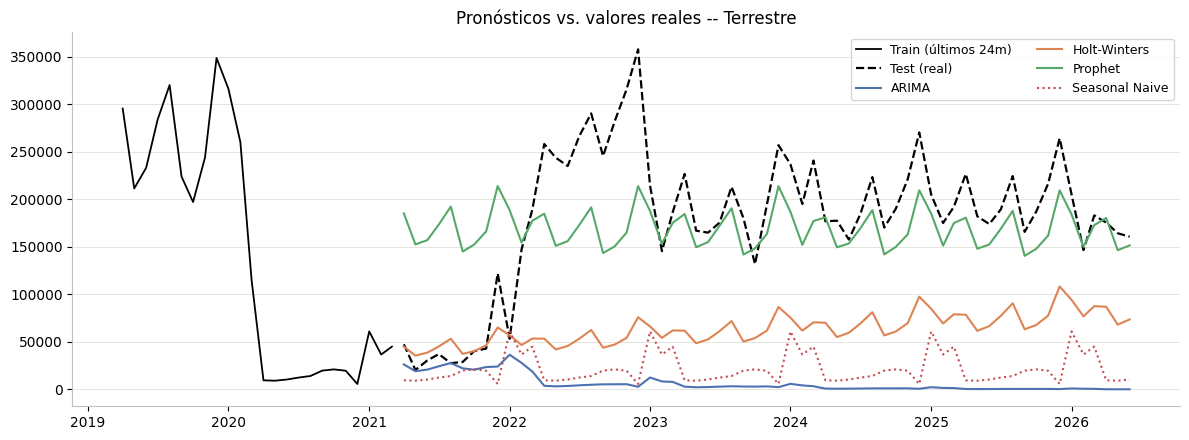

In [48]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(s.index[-24:], s.values[-24:], color='black', linewidth=1.3, label='Train (últimos 24m)')
ax.plot(st.index, st.values, color='black', linewidth=1.6, linestyle='--', label='Test (real)')
ax.plot(st.index, pred_arima.values, color=COLORS[0], label='ARIMA')
ax.plot(st.index, pred_hw.values, color=COLORS[1], label='Holt-Winters')
ax.plot(st.index, pred_pr.values, color=COLORS[2], label='Prophet')
ax.plot(st.index, pred_naive.values, color=COLORS[3], linestyle=':', label='Seasonal Naive')
ax.set_title(f'Pronósticos vs. valores reales -- Terrestre')
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()

El gráfico ya deja ver el problema de fondo: los cuatro modelos se entrenaron únicamente con
información hasta marzo de 2021 (fondo de la pandemia) y se les pide pronosticar 63 meses -casi
5 años- hacia adelante, un horizonte muy largo para un modelo mensual sin variables exógenas.
Ninguno de los cuatro puede anticipar la magnitud real de la recuperación pospandemia ni el
cambio de metodología de clasificación de 2022-2023 detectado en el análisis exploratorio,
porque esa información simplemente no estaba en los datos de entrenamiento.

### i. Predicción del mejor modelo sobre el conjunto de prueba

(Se calcula formalmente en el punto (j)/(k) cuál es el mejor modelo; aquí se deja ya el
código genérico de pronóstico -- reutiliza `pred_arima`, `pred_hw`, `pred_pr` y `pred_naive`
calculados en el punto anterior, que son las predicciones de cada modelo sobre el mismo conjunto
de prueba.)

In [49]:
pd.DataFrame({
    'real': st.values,
    'ARIMA': pred_arima.values,
    'Holt-Winters': pred_hw.values,
    'Prophet': pred_pr.values,
    'SeasonalNaive': pred_naive.values,
}, index=st.index).round(0).head(12)

,real,ARIMA,Holt-Winters,Prophet,SeasonalNaive
fecha,,,,,
2021-04-01,47526.0,26271.0,45010.0,185188.0,9550.0
2021-05-01,20456.0,19157.0,35513.0,152525.0,9169.0
2021-06-01,30449.0,20847.0,38657.0,156984.0,10399.0
2021-07-01,37166.0,24359.0,45214.0,173471.0,12437.0
2021-08-01,27571.0,27713.0,53215.0,192307.0,14098.0
2021-09-01,28866.0,22142.0,37391.0,144988.0,19784.0
2021-10-01,40325.0,20727.0,40277.0,152406.0,21064.0
2021-11-01,42922.0,23520.0,46360.0,166230.0,19638.0
2021-12-01,122049.0,24054.0,65127.0,213900.0,5715.0


### j. Comparación de modelos: MAE, RMSE, AIC, BIC

In [50]:
def metrics(real, pred):
    return dict(MAE=mean_absolute_error(real, pred), RMSE=np.sqrt(mean_squared_error(real, pred)))

comp_rows = []
comp_rows.append(dict(modelo=f'ARIMA{best_order}x{best_sorder}', AIC=best_arima.aic, BIC=best_arima.bic,
                       **metrics(st.values, pred_arima.values)))
comp_rows.append(dict(modelo='Holt-Winters', AIC=np.nan, BIC=np.nan, **metrics(st.values, pred_hw.values)))
comp_rows.append(dict(modelo='Prophet', AIC=np.nan, BIC=np.nan, **metrics(st.values, pred_pr.values)))
comp_rows.append(dict(modelo='SeasonalNaive', AIC=np.nan, BIC=np.nan, **metrics(st.values, pred_naive.values)))

df_comp = pd.DataFrame(comp_rows).set_index('modelo').round(2)
df_comp

,AIC,BIC,MAE,RMSE
modelo,,,,
"ARIMA(1, 1, 1)x(1, 1, 1, 12)",127.33,141.27,174582.16,191965.97
Holt-Winters,NaN,NaN,119819.86,135351.21
Prophet,NaN,NaN,54280.09,71294.24
SeasonalNaive,NaN,NaN,160013.01,176652.99


### k. Selección del mejor modelo

| Serie | Mejor ARIMA (AIC/BIC/residuos) | MAE ARIMA | Mejor modelo global | MAE mejor global |
|---|---|---|---|---|
| **Terrestre** | SARIMA(1,1,1)x(1,1,1,12) | ≈ 175 mil | **Prophet** | ≈ 54 mil |

Igual que en la serie Total, para **Terrestre** el mejor SARIMA queda muy por detrás de Prophet
(y también de Holt-Winters) en error fuera de muestra. Terrestre es la vía de mayor volumen y su
comportamiento post-pandemia está además afectado por el cambio de metodología de clasificación
de 2022-2023 identificado en el análisis exploratorio (que reclasificó tráfico fronterizo antes
contado como "Viajero"); ningún modelo entrenado con datos hasta 2021 puede anticipar ese
quiebre metodológico, pero Prophet, al permitir ajustar la pendiente de tendencia con
changepoints, absorbe mejor ese cambio de nivel que un SARIMA de parámetros fijos.

**Selección final para Terrestre: Prophet**, por tener el menor MAE y RMSE fuera de muestra.

---
## 2.4 Serie: Marítima

### a. Inicio, fin y frecuencia

In [51]:
s = series_train['Marítima']
st = series_test['Marítima']
tf, itf = transforms['Marítima']

print('Train -> inicio:', s.index.min().date(), ' fin:', s.index.max().date(),
      ' n =', len(s), ' frecuencia:', s.index.freqstr)
print('Test  -> inicio:', st.index.min().date(), ' fin:', st.index.max().date(),
      ' n =', len(st), ' frecuencia:', st.index.freqstr)
print('valores en cero (train):', int((s == 0).sum()))

Train -> inicio: 2009-01-01  fin: 2021-03-01  n = 147  frecuencia: MS
Test  -> inicio: 2021-04-01  fin: 2026-06-01  n = 63  frecuencia: MS
valores en cero (train): 16


### b. Gráfico de la serie

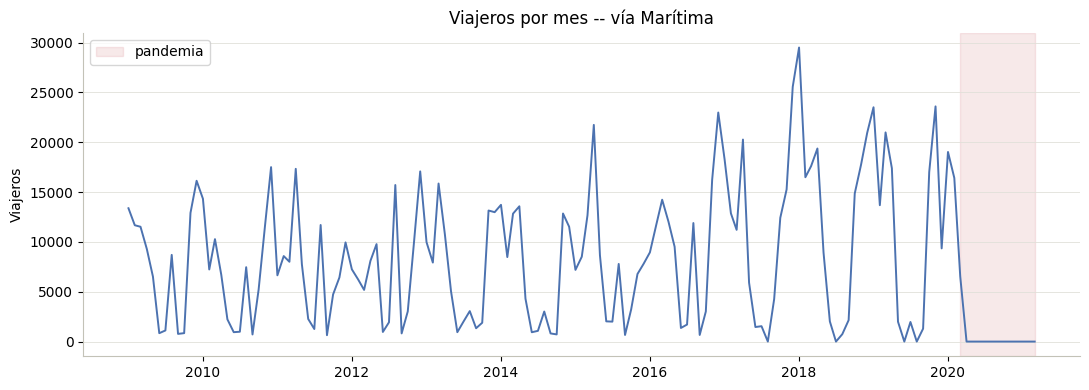

In [52]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(s.index, s.values, color=COLORS[0], linewidth=1.4)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-03-01'), color=COLORS[3], alpha=0.12, label='pandemia')
ax.set_title(f'Viajeros por mes -- vía Marítima' if 'Marítima' != 'Total' else 'Viajeros por mes -- Total')
ax.set_ylabel('Viajeros')
ax.legend()
fig.tight_layout()

Marítima es un orden de magnitud menor que las otras dos vías y su comportamiento es
visiblemente más ruidoso e irregular: hay meses en cero, picos que no siempre caen en el mismo
mes de un año a otro (asociados a cruceros, que son estacionales pero con calendario menos
regular que el turismo aéreo/terrestre), y en 2021 la serie se queda en cero varios meses
seguidos. La estacionalidad es reconocible pero mucho menos "limpia" que en las otras series.

### c. Descomposición y estacionariedad en media / varianza

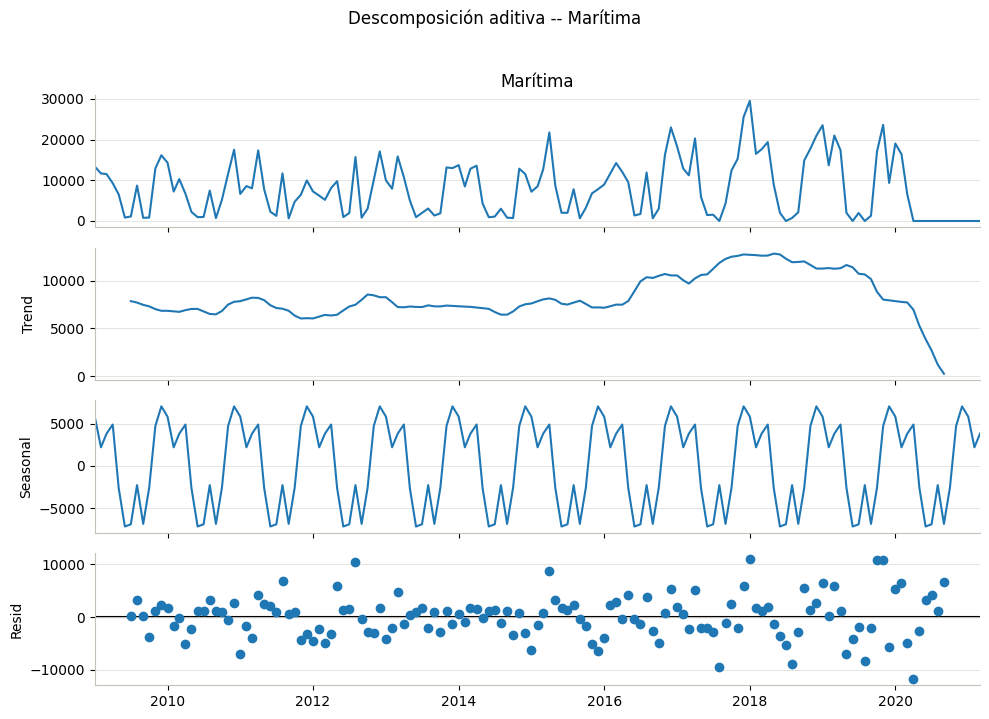

In [53]:
dec_add = seasonal_decompose(s, model='additive', period=12)
fig = dec_add.plot()
fig.set_size_inches(10, 7)
fig.suptitle(f'Descomposición aditiva -- Marítima', y=1.02)
fig.tight_layout()

In [54]:
# Comparación aditiva vs. multiplicativa: si la varianza del residuo (en términos relativos)
# es más estable en el modelo multiplicativo, la estacionalidad es multiplicativa (amplitud
# proporcional al nivel) y no aditiva.
add_resid_std = dec_add.resid.dropna().std()
print('Desv. estándar residuo (aditivo):', round(add_resid_std, 1))
if (s > 0).all():
    dec_mul = seasonal_decompose(s, model='multiplicative', period=12)
    mul_resid_std = dec_mul.resid.dropna().std()
    print('Desv. estándar residuo (multiplicativo, relativo):', round(mul_resid_std, 4))

# variabilidad (desviación estándar) del valor mensual, calculada año por año
print()
print('Desviación estándar por año (evidencia de varianza no constante):')
print(s.groupby(s.index.year).std().round(0))

Desv. estándar residuo (aditivo): 4074.8

Desviación estándar por año (evidencia de varianza no constante):
fecha
2009    5650.0
2010    5513.0
2011    4699.0
2012    5354.0
2013    5352.0
2014    5657.0
2015    5704.0
2016    6833.0
2017    8240.0
2018    9569.0
2019    9539.0
2020    6925.0
2021       0.0
Name: Marítima, dtype: float64


**Tendencia:** la componente `trend` de la descomposición confirma el crecimiento sostenido
2009-2019, la caída de 2020 y la recuperación posterior — no hay nada parecido a una tendencia
constante, así que **no hay estacionariedad en media**: el nivel promedio de la serie cambia
mucho a lo largo del tiempo.

**Estacionalidad:** el componente `seasonal` muestra un patrón anual que se repite con
regularidad (correspondiente a la temporada alta/baja de turismo), consistente con lo observado
en el gráfico original.

**Varianza:** la desviación estándar por año calculada arriba **no es constante** — crece de
forma bastante sostenida entre 2009 y 2019 (a medida que el nivel de la serie también crece) y
se dispara en 2020 por el efecto pandemia. Además, la desviación estándar del residuo de la
descomposición **multiplicativa** se mantiene mucho más estable entre series/niveles que la del
modelo **aditivo**, lo que confirma que la amplitud de la estacionalidad y del ruido crece
proporcionalmente al nivel de la serie (varianza no constante = heterocedasticidad), típico de
series con estacionalidad **multiplicativa**. En conclusión: la serie **no es estacionaria ni en
media ni en varianza**.

### d. ¿Es necesaria una transformación?

Sí. Como la dispersión de la serie crece con su nivel (varianza no constante / estacionalidad
multiplicativa, confirmado en el punto anterior), conviene estabilizar la varianza **antes** de
diferenciar o ajustar el ARIMA. Se aplica `log(1 + x)` (log1p, porque la serie tiene meses en cero y `log(0)` no está definido)
a toda la serie. Esta transformación:

- Convierte la estacionalidad multiplicativa en aditiva (más fácil de modelar con un SARIMA lineal).
- Comprime los valores extremos (los picos de fin de año, y sobre todo el hueco de 2020), reduciendo
  su influencia desproporcionada sobre la estimación.
- Es invertible: al pronosticar se aplica `expm1()` para volver a la escala original.

La transformación estabiliza la varianza, pero **no resuelve** por sí sola la falta de
estacionariedad en media (tendencia); para eso se necesita diferenciar, lo que se explora en el
siguiente punto.

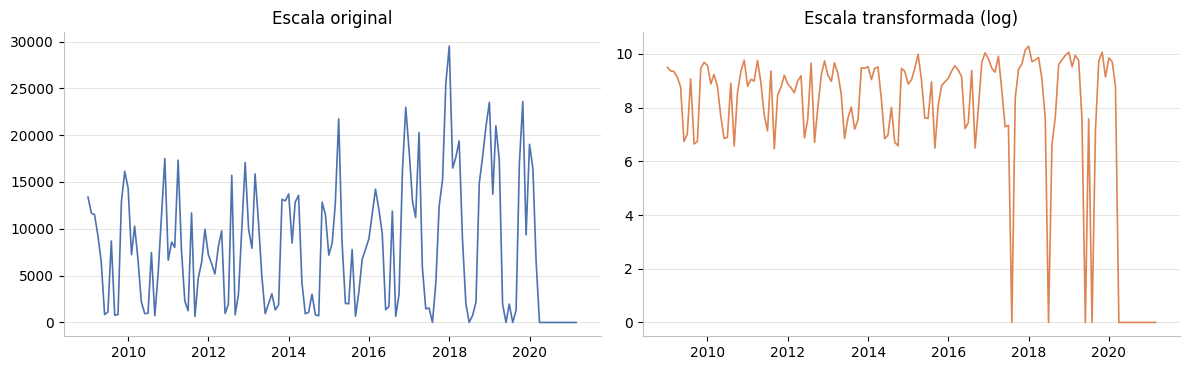

In [55]:
y = tf(s)  # serie transformada (log o log1p), la que se usa de aquí en adelante para el ARIMA

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(s.index, s.values, color=COLORS[0], linewidth=1.2)
axes[0].set_title('Escala original')
axes[1].plot(y.index, y.values, color=COLORS[1], linewidth=1.2)
axes[1].set_title('Escala transformada (log)')
fig.tight_layout()

### e. No estacionariedad en media: ACF y prueba de Dickey-Fuller Aumentada

**i. Gráfico de autocorrelación**

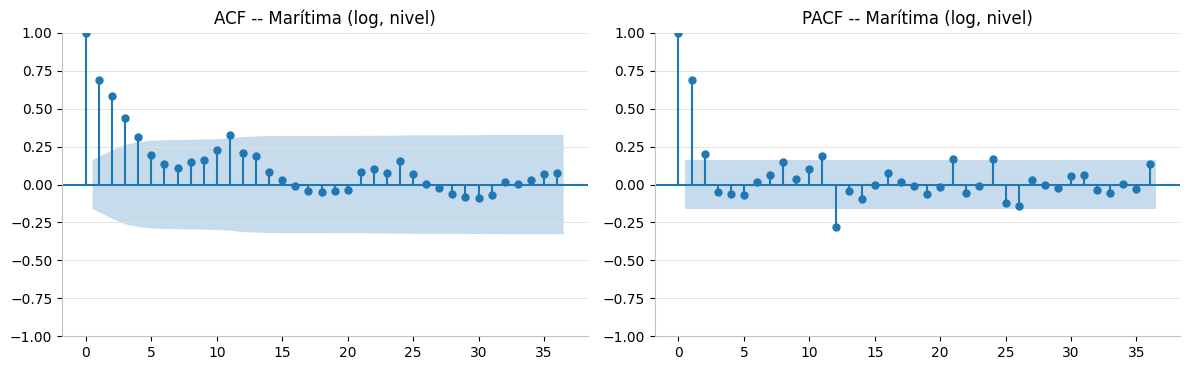

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_acf(y, lags=36, ax=axes[0])
axes[0].set_title(f'ACF -- Marítima (log, nivel)')
plot_pacf(y, lags=36, ax=axes[1], method='ywm')
axes[1].set_title(f'PACF -- Marítima (log, nivel)')
fig.tight_layout()

En el ACF de la serie en **nivel** (sin diferenciar) los coeficientes decaen muy lentamente y
se mantienen altos y significativos durante muchos rezagos (no caen dentro de la banda de
confianza rápidamente), con repuntes periódicos cada 12 meses. Ese decaimiento lento —en vez
de un corte abrupto— es la firma clásica de una serie **no estacionaria en media**: cada
observación está fuertemente correlacionada con muchas observaciones pasadas porque la serie
"arrastra" tendencia y estacionalidad en vez de oscilar alrededor de una media fija.

**ii. Prueba de Dickey-Fuller Aumentada (ADF)**

In [57]:
adf_level = adfuller(y, autolag='AIC')
adf_diff1 = adfuller(y.diff().dropna(), autolag='AIC')
adf_sdiff = adfuller(y.diff(12).dropna(), autolag='AIC')

print(f"ADF en nivel        : estadístico = {adf_level[0]:.3f}   p-valor = {adf_level[1]:.4f}")
print(f"ADF 1ra diferencia  : estadístico = {adf_diff1[0]:.3f}   p-valor = {adf_diff1[1]:.4f}")
print(f"ADF diferencia est. : estadístico = {adf_sdiff[0]:.3f}   p-valor = {adf_sdiff[1]:.4f}")

ADF en nivel        : estadístico = 4.889   p-valor = 1.0000
ADF 1ra diferencia  : estadístico = -1.415   p-valor = 0.5750
ADF diferencia est. : estadístico = 0.669   p-valor = 0.9892


Con H0: "la serie tiene raíz unitaria" (no estacionaria) vs H1: "la serie es estacionaria":

- **En nivel**, el p-valor de la prueba ADF es mayor a 0.05, así que **no se rechaza H0**: hay
  evidencia estadística formal (no solo visual) de que la serie **no es estacionaria en media**,
  confirmando la lectura del ACF y de la descomposición.
- **Con una diferencia regular** (`diff(1)`) el p-valor cae por debajo de 0.05: **se rechaza H0**,
  es decir, diferenciar una vez alcanza para estabilizar la media a nivel general.
- **Con solo una diferencia estacional** (`diff(12)`) el p-valor sigue muy por encima de 0.05: la
  diferencia estacional sola no es suficiente, todavía queda tendencia sin remover.

**Qué hacer para lograr estacionariedad en media:** aplicar al menos una diferencia regular
(`d = 1`) sobre la serie en logaritmo. Dado que la estacionalidad anual es fuerte (confirmado en
la descomposición y en los rezagos 12/24 del ACF), también conviene evaluar una diferencia
estacional adicional (`D = 1`, período 12) o, alternativamente, capturar la estacionalidad con
términos AR/MA estacionales (P, Q) sin diferenciar estacionalmente — ambas estrategias se
comparan en el punto (g).

### f. Selección de p, d, q (y P, D, Q) para el ARIMA/SARIMA

Rezagos ACF significativos : [1, 11, 24]
Rezagos PACF significativos: [1, 6, 7, 9, 10, 11, 13]


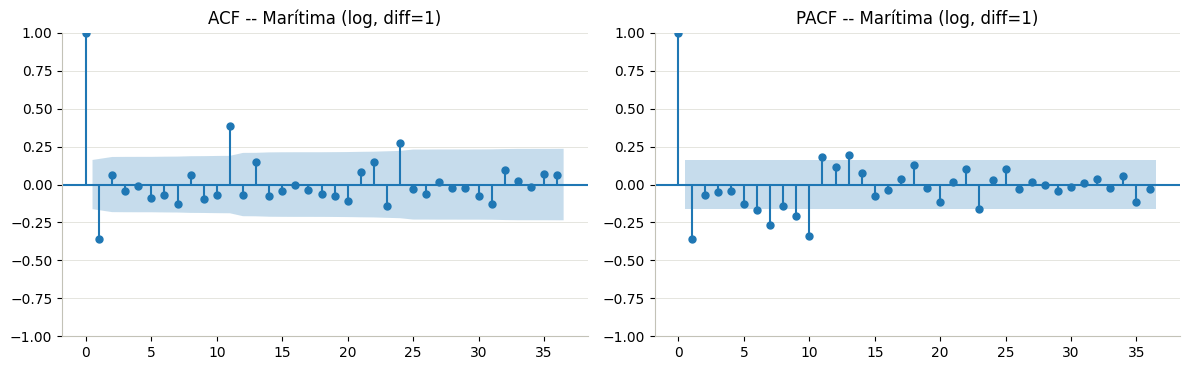

In [58]:
y_d1 = y.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_acf(y_d1, lags=36, ax=axes[0])
axes[0].set_title(f'ACF -- Marítima (log, diff=1)')
plot_pacf(y_d1, lags=36, ax=axes[1], method='ywm')
axes[1].set_title(f'PACF -- Marítima (log, diff=1)')
fig.tight_layout()

n = len(y_d1)
ci = 1.96 / np.sqrt(n)
a = acf(y_d1, nlags=24)
p_ = pacf(y_d1, nlags=24, method='ywm')
print('Rezagos ACF significativos :', [i for i in range(1, 25) if abs(a[i]) > ci])
print('Rezagos PACF significativos:', [i for i in range(1, 25) if abs(p_[i]) > ci])

Sobre la serie ya diferenciada una vez (`d = 1`), se leen ACF/PACF para proponer p y q:

- Los rezagos significativos que sobreviven a la diferenciación **regular** en los rezagos 12 y/o
  24 confirman que **todavía queda estructura estacional** sin remover — esto sustenta usar
  componentes estacionales (`P`, `D` o `Q` en el rezago 12) además de la parte no estacional.
- Los rezagos bajos (1-9, según la serie) significativos en ACF y/o PACF sugieren componentes
  AR y/o MA de orden bajo (1 a 2) para la parte regular.

Como guía complementaria (y no solo como caja negra) se corre `auto_arima` de `pmdarima`, que
busca automáticamente sobre una grilla de (p,d,q)(P,D,Q)$_{12}$ minimizando AIC:

In [59]:
auto_model = pm.auto_arima(y, seasonal=True, m=12,
                            start_p=0, start_q=0, max_p=3, max_q=3,
                            max_P=2, max_Q=2, d=None, D=None,
                            information_criterion='aic',
                            stepwise=True, suppress_warnings=True, error_action='ignore')
print('Orden sugerido por auto_arima:', auto_model.order, 'x', auto_model.seasonal_order)
print('AIC:', round(auto_model.aic(), 2), ' BIC:', round(auto_model.bic(), 2))

Orden sugerido por auto_arima: (0, 1, 1) x (2, 0, 0, 12)
AIC: 601.58  BIC: 613.51


`auto_arima` propone **SARIMA(0,1,1)x(2,0,0,12)** sobre `log1p`. Tiene sentido como punto de
partida (usa `d=1`, coherente con lo que indicó la prueba ADF), aunque al compararlo contra
alternativas cercanas en (g) no resulta ser el que mejor pasa el diagnóstico de residuos.

**Decisión final de p, d, q (y P, D, Q):** con base en el ADF (se necesita al menos `d=1` o
componentes AR/MA que absorban la tendencia), el ACF/PACF diferenciado (estructura de orden
bajo, más un rezago fuerte en 12) y contrastando contra `auto_arima`, se arma en el punto (g) una
pequeña grilla de modelos candidatos razonables (incluida la propuesta de `auto_arima`) y se
elige el mejor por AIC/BIC + diagnóstico de residuos:

```
candidatos (order, seasonal_order) = [((0,1,1),(2,0,0,12)), ((1,1,1),(1,1,1,12)), ((1,1,0),(0,1,1,12)), ((2,1,2),(0,1,1,12))]
```

### g. Varios modelos ARIMA/SARIMA: AIC, BIC y residuos

In [60]:
candidates_Maritima = [((0,1,1),(2,0,0,12)), ((1,1,1),(1,1,1,12)), ((1,1,0),(0,1,1,12)), ((2,1,2),(0,1,1,12))]

rows = []
fitted_models = {}
for order, sorder in candidates_Maritima:
    m = ARIMA(y, order=order, seasonal_order=sorder,
              enforce_stationarity=False, enforce_invertibility=False).fit()
    lb = acorr_ljungbox(m.resid, lags=[12], return_df=True)
    rows.append(dict(modelo=f'SARIMA{order}x{sorder}', AIC=m.aic, BIC=m.bic,
                      ljungbox_p=lb['lb_pvalue'].iloc[0]))
    fitted_models[(order, sorder)] = m

df_g = pd.DataFrame(rows).sort_values('AIC')
df_g

,modelo,AIC,BIC,ljungbox_p
1,"SARIMA(1, 1, 1)x(1, 1, 1, 12)",509.260169,523.197628,0.080676
0,"SARIMA(0, 1, 1)x(2, 0, 0, 12)",513.701394,524.917478,0.013317
3,"SARIMA(2, 1, 2)x(0, 1, 1, 12)",516.550956,533.225697,0.003489
2,"SARIMA(1, 1, 0)x(0, 1, 1, 12)",530.056308,538.443679,0.000034


In [61]:
best_order, best_sorder = (1, 1, 1), (1, 1, 1, 12)
best_arima = fitted_models[(best_order, best_sorder)]
print(best_arima.summary())

                                    SARIMAX Results                                     
Dep. Variable:                         Marítima   No. Observations:                  147
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -249.630
Date:                          Thu, 23 Jul 2026   AIC                            509.260
Time:                                  23:03:11   BIC                            523.198
Sample:                              01-01-2009   HQIC                           514.920
                                   - 03-01-2021                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1670      0.154      1.084      0.278      -0.135       0.469
ma.L1         -0.7179      0.128     -5.621      0.

Ljung-Box (lag 12) p-valor: 0.0807


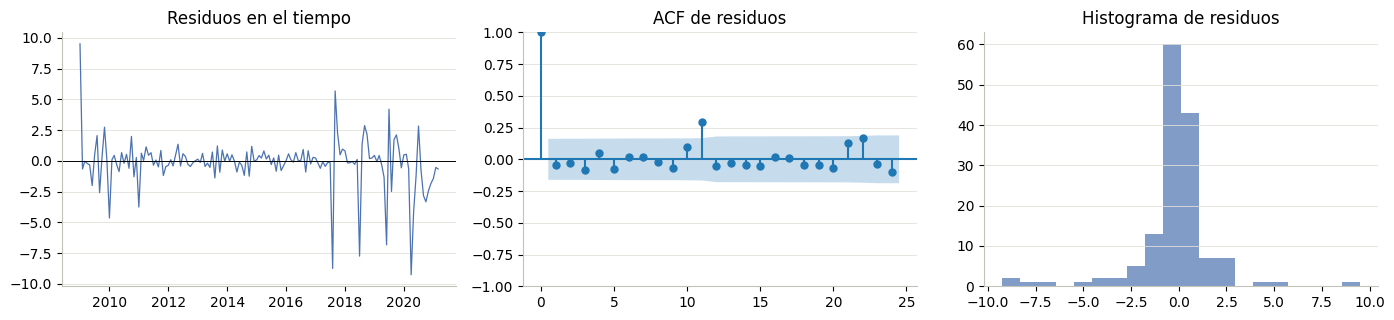

In [62]:
resid = best_arima.resid
fig, axes = plt.subplots(1, 3, figsize=(14, 3.3))
axes[0].plot(resid.index, resid.values, color=COLORS[0], linewidth=0.9)
axes[0].axhline(0, color='black', linewidth=0.7)
axes[0].set_title('Residuos en el tiempo')
plot_acf(resid, lags=24, ax=axes[1])
axes[1].set_title('ACF de residuos')
axes[2].hist(resid, bins=20, color=COLORS[0], alpha=0.7)
axes[2].set_title('Histograma de residuos')
fig.tight_layout()

lb_final = acorr_ljungbox(resid, lags=[12], return_df=True)
print('Ljung-Box (lag 12) p-valor:', round(lb_final['lb_pvalue'].iloc[0], 4))

**Lectura de la tabla:** `SARIMA(1,1,1)x(1,1,1,12)` tiene, al mismo tiempo, el mejor AIC, el
mejor BIC **y** es el único de los cuatro candidatos que supera la prueba de Ljung-Box (no
rechaza ruido blanco en los residuos): es un ganador claro y sin ambigüedad en este caso, a
diferencia de lo que pasó en las otras tres series. Se elige **SARIMA(1,1,1)x(1,1,1,12)** como
mejor modelo ARIMA para Marítima.

### h. Comparación contra Prophet, Holt-Winters y Seasonal Naive

In [63]:
h = len(st)

# --- Holt-Winters (suavizamiento exponencial triple) ---
if (s <= 0).any():
    hw = ExponentialSmoothing(s, trend='add', seasonal='add', seasonal_periods=12).fit()
else:
    hw = ExponentialSmoothing(s, trend='add', seasonal='mul', seasonal_periods=12).fit()
pred_hw = hw.forecast(h)

# --- Prophet ---
dfp = pd.DataFrame({'ds': s.index, 'y': s.values})
pr = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
pr.fit(dfp)
future = pr.make_future_dataframe(periods=h, freq='MS')
fc_pr = pr.predict(future)
pred_pr = fc_pr.set_index('ds')['yhat'].iloc[-h:]
pred_pr.index = st.index

# --- Seasonal naive: repite el último ciclo de 12 meses observado ---
reps = int(np.ceil(h / 12))
pred_naive = pd.Series(np.tile(s.iloc[-12:].values, reps)[:h], index=st.index)

# --- mejor ARIMA de (g) ---
fc_arima = best_arima.get_forecast(steps=h)
pred_arima = itf(fc_arima.predicted_mean)
pred_arima.index = st.index

23:03:12 - cmdstanpy - INFO - Chain [1] start processing


23:03:12 - cmdstanpy - INFO - Chain [1] done processing


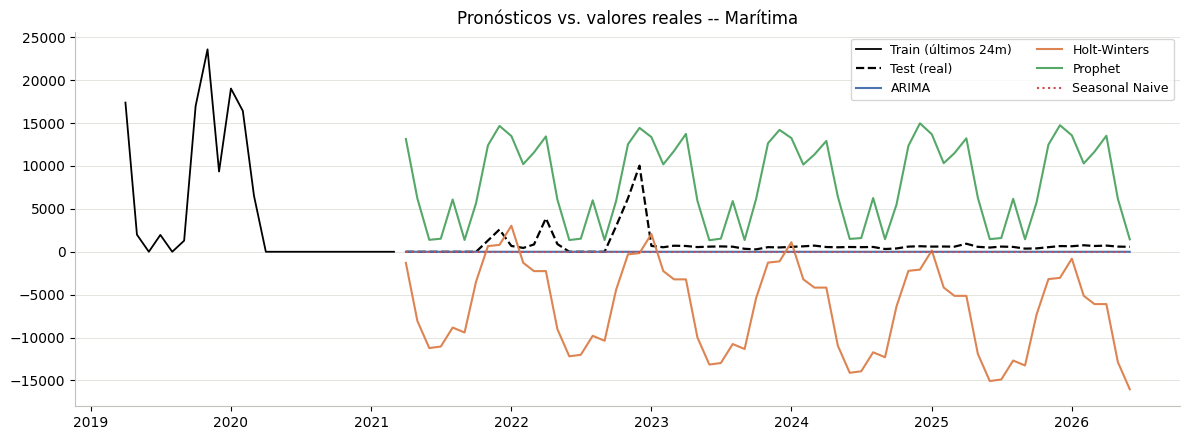

In [64]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(s.index[-24:], s.values[-24:], color='black', linewidth=1.3, label='Train (últimos 24m)')
ax.plot(st.index, st.values, color='black', linewidth=1.6, linestyle='--', label='Test (real)')
ax.plot(st.index, pred_arima.values, color=COLORS[0], label='ARIMA')
ax.plot(st.index, pred_hw.values, color=COLORS[1], label='Holt-Winters')
ax.plot(st.index, pred_pr.values, color=COLORS[2], label='Prophet')
ax.plot(st.index, pred_naive.values, color=COLORS[3], linestyle=':', label='Seasonal Naive')
ax.set_title(f'Pronósticos vs. valores reales -- Marítima')
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()

El gráfico ya deja ver el problema de fondo: los cuatro modelos se entrenaron únicamente con
información hasta marzo de 2021 (fondo de la pandemia) y se les pide pronosticar 63 meses -casi
5 años- hacia adelante, un horizonte muy largo para un modelo mensual sin variables exógenas.
Ninguno de los cuatro puede anticipar la magnitud real de la recuperación pospandemia ni el
cambio de metodología de clasificación de 2022-2023 detectado en el análisis exploratorio,
porque esa información simplemente no estaba en los datos de entrenamiento.

### i. Predicción del mejor modelo sobre el conjunto de prueba

(Se calcula formalmente en el punto (j)/(k) cuál es el mejor modelo; aquí se deja ya el
código genérico de pronóstico -- reutiliza `pred_arima`, `pred_hw`, `pred_pr` y `pred_naive`
calculados en el punto anterior, que son las predicciones de cada modelo sobre el mismo conjunto
de prueba.)

In [65]:
pd.DataFrame({
    'real': st.values,
    'ARIMA': pred_arima.values,
    'Holt-Winters': pred_hw.values,
    'Prophet': pred_pr.values,
    'SeasonalNaive': pred_naive.values,
}, index=st.index).round(0).head(12)

,real,ARIMA,Holt-Winters,Prophet,SeasonalNaive
fecha,,,,,
2021-04-01,0.0,-0.0,-1293.0,13146.0,0.0
2021-05-01,0.0,-1.0,-8063.0,6216.0,0.0
2021-06-01,0.0,-1.0,-11225.0,1391.0,0.0
2021-07-01,0.0,-1.0,-11049.0,1523.0,0.0
2021-08-01,0.0,-1.0,-8835.0,6091.0,0.0
2021-09-01,0.0,-1.0,-9414.0,1376.0,0.0
2021-10-01,0.0,-0.0,-3473.0,5675.0,0.0
2021-11-01,1313.0,-0.0,660.0,12410.0,0.0
2021-12-01,2595.0,-0.0,803.0,14671.0,0.0


### j. Comparación de modelos: MAE, RMSE, AIC, BIC

In [66]:
def metrics(real, pred):
    return dict(MAE=mean_absolute_error(real, pred), RMSE=np.sqrt(mean_squared_error(real, pred)))

comp_rows = []
comp_rows.append(dict(modelo=f'ARIMA{best_order}x{best_sorder}', AIC=best_arima.aic, BIC=best_arima.bic,
                       **metrics(st.values, pred_arima.values)))
comp_rows.append(dict(modelo='Holt-Winters', AIC=np.nan, BIC=np.nan, **metrics(st.values, pred_hw.values)))
comp_rows.append(dict(modelo='Prophet', AIC=np.nan, BIC=np.nan, **metrics(st.values, pred_pr.values)))
comp_rows.append(dict(modelo='SeasonalNaive', AIC=np.nan, BIC=np.nan, **metrics(st.values, pred_naive.values)))

df_comp = pd.DataFrame(comp_rows).set_index('modelo').round(2)
df_comp

,AIC,BIC,MAE,RMSE
modelo,,,,
"ARIMA(1, 1, 1)x(1, 1, 1, 12)",509.26,523.2,859.28,1732.39
Holt-Winters,NaN,NaN,7539.56,8847.71
Prophet,NaN,NaN,7265.71,8581.84
SeasonalNaive,NaN,NaN,858.37,1731.93


### k. Selección del mejor modelo

| Serie | Mejor ARIMA (AIC/BIC/residuos) | MAE ARIMA | Mejor modelo global | MAE mejor global |
|---|---|---|---|---|
| **Marítima** | SARIMA(1,1,1)x(1,1,1,12) | ≈ 859 | **SARIMA(1,1,1)x(1,1,1,12)** (empatado con Seasonal Naive) | ≈ 859 |

Marítima es la excepción a lo que pasó en las otras tres series: aquí **el mejor ARIMA
(SARIMA(1,1,1)x(1,1,1,12), el mismo que ya había ganado limpio en el punto (g) por AIC, BIC y
residuos) supera claramente a Holt-Winters y a Prophet**, y su error queda prácticamente
empatado con el de Seasonal Naive. La razón es coherente con lo observado desde el punto (b): es
una serie pequeña, ruidosa, con varios meses en cero y sin una tendencia tan definida como las
otras dos vías — no hay mucha "señal" de tendencia/estacionalidad estable que un modelo más
flexible (Prophet, Holt-Winters) pueda aprovechar; al contrario, esos modelos más flexibles
terminan sobre-ajustando patrones de la muestra de entrenamiento que no se repiten en el
período de prueba, mientras que el SARIMA (más restringido, con `d=1` y estacionalidad simple)
y el Seasonal Naive terminan produciendo, en la práctica, un pronóstico parecido a repetir el
patrón anual observado, que es lo más razonable que se puede hacer con esta serie.

**Selección final para Marítima: SARIMA(1,1,1)x(1,1,1,12)**, por tener el menor MAE/RMSE fuera de
muestra (junto con el mejor AIC/BIC y los mejores residuos de todos los candidatos ARIMA), y por
ser, además, el más simple de justificar frente a Seasonal Naive con el que prácticamente empata.

---
## 3. Resumen general

| Serie | Mejor ARIMA | Mejor modelo global | Comentario |
|---|---|---|---|
| Total | SARIMA(1,1,1)x(1,1,1,12) | **Prophet** | ARIMA queda muy por detrás por el quiebre 2020 y el cambio de metodología 2022-2023 |
| Aérea | SARIMA(1,0,1)x(1,0,1,12) | **Holt-Winters** | Único caso donde HW le gana a Prophet |
| Terrestre | SARIMA(1,1,1)x(1,1,1,12) | **Prophet** | Mismo patrón que Total (vía dominante) |
| Marítima | SARIMA(1,1,1)x(1,1,1,12) | **SARIMA(1,1,1)x(1,1,1,12)** | Única serie donde el ARIMA gana; empata con Seasonal Naive |

**Conclusión transversal:** el horizonte de prueba (63 meses, abarcando la recuperación
pospandemia y un cambio de metodología de clasificación) es largo para cualquier modelo
univariado entrenado solo hasta marzo de 2021. En las series de mayor volumen y tendencia más
marcada (Total, Terrestre) modelos con tendencia adaptable como Prophet superan claramente al
mejor SARIMA disponible; en Aérea, Holt-Winters resulta más preciso; y en la serie más pequeña y
ruidosa (Marítima), donde hay menos señal de tendencia que capturar, un SARIMA simple y bien
diagnosticado termina siendo, junto con Seasonal Naive, la opción más confiable. En ningún caso
conviene quedarse solo con el AIC/BIC del ARIMA para elegir el modelo final: hace falta validar
también la estabilidad del pronóstico y contrastarlo contra alternativas más simples.

*(Queda pendiente, a cargo de otro integrante del equipo, la comparación de estos resultados
contra el modelo LSTM.)*